# Time Series-Based Prediction of Fruit and Vegetable Market Prices


**Objective:** \
The present project implements and compares the results of two algorithms whose predicts the price of vegetables and fruits using time series data. The dataset used [Time Series Price Vegetables and Fruits](https://www.kaggle.com/datasets/ramkrijal/agriculture-vegetables-fruits-time-series-prices) from kaggle. The pipeline of the process includes preprocessing, training, evaluation, hyperparameter optimization, and explainability.

# Model Application

## 1. Data Preprocessing. 

Importing libraries section, crucial to begin any project.

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern
from scipy.optimize import minimize
from scipy.stats import norm
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, Any, List
import warnings
import shap

warnings.filterwarnings('ignore')

The next sections load and preprocess the dataset. First it must be uploaded.

In [3]:
# Read a pandas DataFrame
df = pd.read_csv("kalimati_tarkari_dataset.csv", delimiter=",")
df.head()

,SN,Commodity,Date,Unit,Minimum,Maximum,Average
0,0,Tomato Big(Nepali),2013-06-16,Kg,35.0,40.0,37.5
1,1,Tomato Small(Local),2013-06-16,Kg,26.0,32.0,29.0
2,2,Potato Red,2013-06-16,Kg,20.0,21.0,20.5
3,3,Potato White,2013-06-16,Kg,15.0,16.0,15.5
4,4,Onion Dry (Indian),2013-06-16,Kg,28.0,30.0,29.0


Its is necessary to analyze the dataset. First, let's check some general info. There are 197161 rows and, according with the columns, It seems that there are no missing values. However, it is necessary to double-check them.

In [4]:
# Check general info of the dataset
print("General info of the dataset:")
print(df.info())

# CHeck for missing values
print("Missing values in each column:")
df_drp_mssing = df.isnull().sum()
print(df_drp_mssing)
# Check for nan values
print("NaN values in each column:")
df_drp_nan = df.isna().sum()
print(df_drp_nan)

General info of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197161 entries, 0 to 197160
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   SN         197161 non-null  int64  
 1   Commodity  197161 non-null  object 
 2   Date       197161 non-null  object 
 3   Unit       197161 non-null  object 
 4   Minimum    197161 non-null  float64
 5   Maximum    197161 non-null  float64
 6   Average    197161 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 10.5+ MB
None
Missing values in each column:
SN           0
Commodity    0
Date         0
Unit         0
Minimum      0
Maximum      0
Average      0
dtype: int64
NaN values in each column:
SN           0
Commodity    0
Date         0
Unit         0
Minimum      0
Maximum      0
Average      0
dtype: int64


There are no missing values. Next, To preprocess the data in the columns, first it is necessary to check the sequence number (SN), if it has the same unique numbers as rows of the dataset, drop it. Then, the Date column is going to be converted from object to date.

In [5]:
# Sequence Number processing
# Check unique values in object columns
print("Sequence Number processing")
SN_unique = df['SN'].nunique()
print(f"Unique values in SN: {SN_unique}")
# if the sequence number (SN) has the same unique numbers as rows of the dataset, drop it
if SN_unique == len(df):
    print("SN has the same unique numbers as rows. Dropping SN column.")
    # Drop irrelevant columns
    df_drp = df.drop(columns=['SN'])

# Date processing
# Convert the only date column to date type
print("Date processing")
df_drp['Date'] = pd.to_datetime(df_drp['Date'], format='%Y-%m-%d')

Sequence Number processing
Unique values in SN: 197161
SN has the same unique numbers as rows. Dropping SN column.
Date processing


The Unit column processing has some considerations. It is going to be ckecked how many units has the data and if it has a dominant one, it is going to be kept. Then, considering that it is a text, typos are analyzed and processed. 

In [6]:
# Unit processing
# Check how many unique units are in the dataset
unit_counts = df_drp['Unit'].value_counts()
print("Unique units in the dataset:")
print(unit_counts)
# There is a typo in the unit column, so it is necessary to fix it
print("Fixing and regularizing the Unit column")
# Replace 'KG' with 'Kg'
df_drp['Unit'] = df_drp['Unit'].replace({'KG': 'Kg'})
# Dropping the rest of units (1 Pc and Doz) as they are not relevant for the analysis
df_unt = df_drp[df_drp['Unit'].isin(['Kg', 'g'])]
# Checking the unique values in the Unit column after processing
print("Unique units after processing:")
print(df_unt['Unit'].unique())
# Now that the dataset has only one unit, drop the Unit column
df_unt_prc = df_unt.drop(columns=['Unit'])


Unique units in the dataset:
Unit
Kg      184408
KG        6889
1 Pc      3120
Doz       2744
Name: count, dtype: int64
Fixing and regularizing the Unit column
Unique units after processing:
['Kg']


As it can be seen, there are 128 commodities. Considering the max and min from commodities, there must be unbalanced commodities, thus, not all of them will be processed. The top 10 commodities are chosen. These are balanced, therefore, the model won't have any problem in the task.

In [7]:
# Commodities processing
print("\nCommodities processing")
# Check unique values in commodities
commodities_unique = df_unt_prc['Commodity'].nunique()
print(f"Number of Commodities: {commodities_unique}")

# Counting the occurrences of commodities
top_commodities = df_unt_prc['Commodity'].value_counts()
# Showing the max value of all commodities
max_commodity_value = top_commodities.max()
print(f"Max commodity value: {max_commodity_value}")
# Showing the min value of all commodities
min_commodity_value = top_commodities.min()
print(f"Min commodity value: {min_commodity_value}")

# To avoid biased results, we will only keep commodities with a value greater than or equal to 2700
print("Filtering top commodities with value >= 2700")
top_commodities_count = top_commodities[(top_commodities >= 2700)].count()
print(f"Number of top commodities with value >= 2700: {top_commodities_count}")

# There are 24 commodities with a value greater than or equal to 2700. We will keep the top 10 commodities
top_commodities = top_commodities[top_commodities >= 2700].head(10)
print("Top 10 commodities:")
print(top_commodities)

# Filter the dataset to keep only the top 10 commodities
df_top_commodities = df_unt_prc[df_unt_prc['Commodity'].isin(top_commodities.index)]

# Store the original commodity names before encoding
commodity_names = df_top_commodities['Commodity'].unique()

# Encoding the Commodity column
print("Encoding the Commodity column")
label_encoder = LabelEncoder()
df_top_commodities['Commodity'] = label_encoder.fit_transform(df_top_commodities['Commodity'])

# Create and display the mapping
commodity_mapping = dict(zip(label_encoder.transform(commodity_names), commodity_names))
print("\nCommodity Mapping (Code -> Name):")
for code, name in commodity_mapping.items():
    print(f"Code {code}: {name}")



Commodities processing
Number of Commodities: 128
Max commodity value: 2751
Min commodity value: 2
Filtering top commodities with value >= 2700
Number of top commodities with value >= 2700: 24
Top 10 commodities:
Commodity
Ginger                  2751
Cauli Local             2750
Cabbage(Local)          2749
Chilli Dry              2748
Raddish White(Local)    2747
Potato Red              2746
Bamboo Shoot            2744
Onion Dry (Indian)      2742
Brd Leaf Mustard        2742
Tomato Small(Local)     2741
Name: count, dtype: int64
Encoding the Commodity column

Commodity Mapping (Code -> Name):
Code 9: Tomato Small(Local)
Code 7: Potato Red
Code 6: Onion Dry (Indian)
Code 2: Cabbage(Local)
Code 3: Cauli Local
Code 8: Raddish White(Local)
Code 1: Brd Leaf Mustard
Code 0: Bamboo Shoot
Code 5: Ginger
Code 4: Chilli Dry


Next, the Date feature is processed: ordering and extracting features to improve the model.

In [8]:
# Sort the DataFrame by Date
print("Processing the Date column")
df_sort = df_top_commodities.sort_values(by='Date')

# Extract temporal features from Date
df_sort['year'] = df_sort['Date'].dt.year
df_sort['day'] = df_sort['Date'].dt.day
df_sort['month'] = df_sort['Date'].dt.month
df_sort['day_of_week'] = df_sort['Date'].dt.dayofweek

# Drop the original Date column
df_sort = df_sort.drop(columns=['Date'])

Processing the Date column


Finally, duplicates are removed

In [9]:
# Check for and remove duplicates before creating the TimeSeries
df_final = df_sort.drop_duplicates()

Let's see the final result of preprocessing.

In [10]:
df_final.head()

,Commodity,Minimum,Maximum,Average,year,day,month,day_of_week
1,9,26.0,32.0,29.0,2013,16,6,6
2,7,20.0,21.0,20.5,2013,16,6,6
4,6,28.0,30.0,29.0,2013,16,6,6
6,2,6.0,10.0,8.0,2013,16,6,6
7,3,30.0,35.0,32.5,2013,16,6,6


Time series must be preprocessed as it before training. A class TimeSeriesPreprocessor is created to perform this task using the followng methods:
- _create_enhanced_features: performs the feature engineering over data. It generates: price change tracking, seasonal cycling (based on month, day, and day of week), and price range (over minimum, maximum and average).
- _get_feature_columns: gets the columns to use as features (date not included)
- _create_sequences_by_commodity: generates sequences of data respecting the commodity sequence. The objective is to keep the order of the sequences through the time series.
- fit_transform: performs the process and generates the features and output sequences for all data.
- transform: transforms new data.
- inverse_transform_y: converts normalized output data into original values.
- get_feature_importance_names: gets features names.
- inverse_transform_X: converts normalized features data into original values.

In [171]:
class TimeSeriesPreprocessor:
    """Enhanced preprocessor for time series price prediction with commodity-aware processing"""
    
    def __init__(self, sequence_length: int = 30, create_features: bool = True):
        self.sequence_length = sequence_length
        self.create_features = create_features
        self.scalers_X = {}  # Separate scalers for each commodity
        self.scalers_y = {}  # Separate scalers for each commodity's target
        self.feature_columns = []
        self.n_features = None
        self.commodities = None
        self.fitted = False
        
    def _create_enhanced_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Create enhanced features for better prediction"""
        df = df.copy()
        
        # Ensure we have the required columns
        required_cols = ['Commodity', 'Minimum', 'Maximum', 'Average', 'year', 'month', 'day', 'day_of_week']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # Create date column for proper sorting
        df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
        df = df.sort_values(['Commodity', 'date'])
        
        print("Creating enhanced features...")
        
        # Group by commodity for feature creation
        enhanced_dfs = []
        
        for commodity in df['Commodity'].unique():
            commodity_df = df[df['Commodity'] == commodity].copy().reset_index(drop=True)
            
            if len(commodity_df) < self.sequence_length + 10:  # Reduced requirement since no lag features
                print(f"Warning: Commodity {commodity} has insufficient data ({len(commodity_df)} rows)")
                continue
            
            # Price change features
            commodity_df['price_change'] = commodity_df['Average'].pct_change()
            commodity_df['price_change_7d'] = commodity_df['Average'].pct_change(periods=7)
            commodity_df['price_acceleration'] = commodity_df['price_change'].diff()
            
            # Seasonal features (cyclical encoding)
            commodity_df['month_sin'] = np.sin(2 * np.pi * commodity_df['month'] / 12)
            commodity_df['month_cos'] = np.cos(2 * np.pi * commodity_df['month'] / 12)
            commodity_df['day_sin'] = np.sin(2 * np.pi * commodity_df['day'] / 31)
            commodity_df['day_cos'] = np.cos(2 * np.pi * commodity_df['day'] / 31)
            commodity_df['dayofweek_sin'] = np.sin(2 * np.pi * commodity_df['day_of_week'] / 7)
            commodity_df['dayofweek_cos'] = np.cos(2 * np.pi * commodity_df['day_of_week'] / 7)
            
            # Price ratio features
            commodity_df['price_range'] = commodity_df['Maximum'] - commodity_df['Minimum']
            commodity_df['price_range_ratio'] = commodity_df['price_range'] / commodity_df['Average']
            commodity_df['price_position'] = (commodity_df['Average'] - commodity_df['Minimum']) / (commodity_df['Maximum'] - commodity_df['Minimum'] + 1e-8)
            
            enhanced_dfs.append(commodity_df)
        
        # Combine all commodities
        enhanced_df = pd.concat(enhanced_dfs, ignore_index=True)
        
        # Fill NaN values (from price change calculations)
        enhanced_df = enhanced_df.fillna(method='bfill').fillna(method='ffill')
        
        # Remove the first few rows that might still have NaN (much fewer now)
        enhanced_df = enhanced_df.dropna()
        
        print(f"Enhanced features created. Shape: {enhanced_df.shape}")

        # Showing a sample of the enhanced DataFrame
        print("Sample of enhanced features:")
        print(enhanced_df.head())

        return enhanced_df
    
    def _get_feature_columns(self, df: pd.DataFrame) -> List[str]:
        """Get the columns to use as features"""
        # Exclude non-feature columns
        exclude_cols = ['Commodity', 'date', 'Average']  # Average is our target
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        return feature_cols
    
    def _create_sequences_by_commodity(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Create sequences while respecting commodity boundaries"""
        X_sequences = []
        y_sequences = []
        commodity_sequences = []
        
        feature_cols = self._get_feature_columns(df)
        self.feature_columns = feature_cols
        
        for commodity in df['Commodity'].unique():
            commodity_df = df[df['Commodity'] == commodity].sort_values('date')
            
            if len(commodity_df) < self.sequence_length + 1:
                print(f"Skipping commodity {commodity}: insufficient data")
                continue
            
            # Get features and target for this commodity
            X_commodity = commodity_df[feature_cols].values
            y_commodity = commodity_df['Average'].values
            
            # Fit scaler for this commodity if not already fitted
            if commodity not in self.scalers_X:
                self.scalers_X[commodity] = RobustScaler()
                self.scalers_y[commodity] = StandardScaler()
                
                X_scaled = self.scalers_X[commodity].fit_transform(X_commodity)
                y_scaled = self.scalers_y[commodity].fit_transform(y_commodity.reshape(-1, 1)).flatten()
            else:
                X_scaled = self.scalers_X[commodity].transform(X_commodity)
                y_scaled = self.scalers_y[commodity].transform(y_commodity.reshape(-1, 1)).flatten()
            
            # Create sequences for this commodity
            for i in range(len(X_scaled) - self.sequence_length):
                X_sequences.append(X_scaled[i:i + self.sequence_length])
                y_sequences.append(y_scaled[i + self.sequence_length])
                commodity_sequences.append(commodity)
        
        return np.array(X_sequences), np.array(y_sequences), np.array(commodity_sequences)
    
    def fit_transform(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Fit the preprocessor and transform the data"""
        # Create enhanced features if requested
        if self.create_features:
            df_processed = self._create_enhanced_features(df)
        else:
            df_processed = df.copy()
            # Still need date column for sorting
            if 'date' not in df_processed.columns:
                df_processed['date'] = pd.to_datetime(df_processed[['year', 'month', 'day']])
        
        # Store commodity list
        self.commodities = df_processed['Commodity'].unique()
        
        # Create sequences
        X_sequences, y_sequences, commodity_sequences = self._create_sequences_by_commodity(df_processed)
        
        # Store feature info
        self.n_features = X_sequences.shape[2]
        self.fitted = True
        
        print(f"Preprocessing complete:")
        print(f"  - Sequences shape: {X_sequences.shape}")
        print(f"  - Targets shape: {y_sequences.shape}")
        print(f"  - Features: {self.n_features}")
        print(f"  - Commodities: {len(self.commodities)}")
        
        return X_sequences, y_sequences, commodity_sequences
    
    def transform(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Transform new data using fitted preprocessor"""
        if not self.fitted:
            raise ValueError("Preprocessor must be fitted before transform")
        
        # Create enhanced features if they were used during fitting
        if self.create_features:
            df_processed = self._create_enhanced_features(df)
        else:
            df_processed = df.copy()
            if 'date' not in df_processed.columns:
                df_processed['date'] = pd.to_datetime(df_processed[['year', 'month', 'day']])
        
        # Create sequences (scalers are already fitted)
        X_sequences, y_sequences, commodity_sequences = self._create_sequences_by_commodity(df_processed)
        
        return X_sequences, y_sequences, commodity_sequences

    def inverse_transform_y(self, y_scaled: np.ndarray, commodities: np.ndarray) -> np.ndarray:
        """Convert scaled prices back to original scale"""
        y_original = np.zeros_like(y_scaled)
        
        for commodity in np.unique(commodities):
            mask = commodities == commodity
            if commodity in self.scalers_y and np.any(mask):
                # Ensure we have the right shape for inverse transform
                y_commodity_scaled = y_scaled[mask].reshape(-1, 1)
                y_commodity_original = self.scalers_y[commodity].inverse_transform(y_commodity_scaled)
                y_original[mask] = y_commodity_original.flatten()
            else:
                if commodity not in self.scalers_y:
                    warnings.warn(f"No scaler found for commodity {commodity}")
                y_original[mask] = y_scaled[mask]
        
        return y_original
    
    def get_feature_importance_names(self) -> List[str]:
        """Get feature names for interpretability"""
        return self.feature_columns if self.feature_columns else []
    
    def inverse_transform_X(self, X_scaled: np.ndarray, commodities: np.ndarray) -> np.ndarray:
        """Convert scaled features back to original scale"""
        X_original = np.zeros_like(X_scaled)
        
        # Handle different input shapes
        if X_scaled.ndim == 3:  # (samples, sequence_length, features)
            for i, commodity in enumerate(commodities):
                if commodity in self.scalers_X:
                    # Transform each sequence
                    for seq_idx in range(X_scaled.shape[1]):
                        X_original[i, seq_idx, :] = self.scalers_X[commodity].inverse_transform(
                            X_scaled[i, seq_idx, :].reshape(1, -1)
                        ).flatten()
                else:
                    warnings.warn(f"No scaler found for commodity {commodity}")
                    X_original[i] = X_scaled[i]
        elif X_scaled.ndim == 2:  # (samples, features)
            for i, commodity in enumerate(commodities):
                if commodity in self.scalers_X:
                    X_original[i, :] = self.scalers_X[commodity].inverse_transform(
                        X_scaled[i, :].reshape(1, -1)
                    ).flatten()
                else:
                    warnings.warn(f"No scaler found for commodity {commodity}")
                    X_original[i] = X_scaled[i]
        
        return X_original

A class DataSplitter to split the dataset, respecting the commodity structure, is created. The methods implemented are the following:
- temporal_split: split data using specific percentage respecting the commodity distribution.
- commodity_aware_split: split the data by commodity.

In [172]:
class DataSplitter:
    """Enhanced data splitting that respects temporal and commodity structure"""
    
    @staticmethod
    def temporal_split(X: np.ndarray, y: np.ndarray, commodities: np.ndarray, 
                      train_ratio: float = 0.6, val_ratio: float = 0.2, 
                      test_ratio: float = 0.2) -> Tuple:
        """Split data temporally while maintaining commodity distribution"""
        
        # Calculate split points
        n_samples = len(X)
        train_end = int(n_samples * train_ratio)
        val_end = int(n_samples * (train_ratio + val_ratio))
        
        # Split the data
        X_train = X[:train_end]
        y_train = y[:train_end]
        commodities_train = commodities[:train_end]
        
        X_val = X[train_end:val_end]
        y_val = y[train_end:val_end]
        commodities_val = commodities[train_end:val_end]
        
        X_test = X[val_end:]
        y_test = y[val_end:]
        commodities_test = commodities[val_end:]
        
        print(f"Temporal split completed:")
        print(f"  - Train: {X_train.shape[0]} samples")
        print(f"  - Val: {X_val.shape[0]} samples") 
        print(f"  - Test: {X_test.shape[0]} samples")
        
        return (X_train, X_val, X_test), (y_train, y_val, y_test), (commodities_train, commodities_val, commodities_test)
    
    @staticmethod
    def commodity_aware_split(X: np.ndarray, y: np.ndarray, commodities: np.ndarray,
                             train_ratio: float = 0.6, val_ratio: float = 0.2,
                             test_ratio: float = 0.2, random_state: int = 42) -> Tuple:
        """Split data ensuring each commodity is represented in all splits"""
        
        X_train_list, X_val_list, X_test_list = [], [], []
        y_train_list, y_val_list, y_test_list = [], [], []
        c_train_list, c_val_list, c_test_list = [], [], []
        
        for commodity in np.unique(commodities):
            # Get indices for this commodity
            commodity_mask = commodities == commodity
            X_commodity = X[commodity_mask]
            y_commodity = y[commodity_mask]
            c_commodity = commodities[commodity_mask]
            
            if len(X_commodity) < 10:  # Skip commodities with too little data
                continue
            
            # Split this commodity's data temporally (no shuffle to maintain time order)
            n_commodity = len(X_commodity)
            train_end = int(n_commodity * train_ratio)
            val_end = int(n_commodity * (train_ratio + val_ratio))
            
            X_train_list.append(X_commodity[:train_end])
            y_train_list.append(y_commodity[:train_end])
            c_train_list.append(c_commodity[:train_end])
            
            X_val_list.append(X_commodity[train_end:val_end])
            y_val_list.append(y_commodity[train_end:val_end])
            c_val_list.append(c_commodity[train_end:val_end])
            
            X_test_list.append(X_commodity[val_end:])
            y_test_list.append(y_commodity[val_end:])
            c_test_list.append(c_commodity[val_end:])
        
        # Concatenate all commodities
        X_train = np.concatenate(X_train_list, axis=0)
        y_train = np.concatenate(y_train_list, axis=0)
        commodities_train = np.concatenate(c_train_list, axis=0)
        
        X_val = np.concatenate(X_val_list, axis=0)
        y_val = np.concatenate(y_val_list, axis=0)
        commodities_val = np.concatenate(c_val_list, axis=0)
        
        X_test = np.concatenate(X_test_list, axis=0)
        y_test = np.concatenate(y_test_list, axis=0)
        commodities_test = np.concatenate(c_test_list, axis=0)
        
        print(f"Commodity-aware split completed:")
        print(f"  - Train: {X_train.shape[0]} samples from {len(np.unique(commodities_train))} commodities")
        print(f"  - Val: {X_val.shape[0]} samples from {len(np.unique(commodities_val))} commodities")
        print(f"  - Test: {X_test.shape[0]} samples from {len(np.unique(commodities_test))} commodities")
        
        return (X_train, X_val, X_test), (y_train, y_val, y_test), (commodities_train, commodities_val, commodities_test)

A function preprocessing_pipeline to control the process is needed. It splits the data by temporal or commodity.

In [173]:
def preprocessing_pipeline(df: pd.DataFrame, sequence_length: int = 30, 
                                  split_method: str = 'commodity_aware') -> Dict:
    """
    Complete preprocessing pipeline
    
    Args:
        df: DataFrame with columns [Commodity, Minimum, Maximum, Average, year, month, day, day_of_week]
        sequence_length: Length of sequences for LSTM
        split_method: 'temporal' or 'commodity_aware'
    
    Returns:
        Dictionary containing all processed data and preprocessor
    """
    
    print("Starting enhanced preprocessing pipeline...")
    
    # Initialize preprocessor
    preprocessor = TimeSeriesPreprocessor(
        sequence_length=sequence_length, 
        create_features=True
    )
    
    # Fit and transform data
    X_sequences, y_sequences, commodity_sequences = preprocessor.fit_transform(df)
    
    # Split data
    splitter = DataSplitter()
    
    if split_method == 'temporal':
        (X_train, X_val, X_test), (y_train, y_val, y_test), (c_train, c_val, c_test) = \
            splitter.temporal_split(X_sequences, y_sequences, commodity_sequences)
    else:  # commodity_aware
        (X_train, X_val, X_test), (y_train, y_val, y_test), (c_train, c_val, c_test) = \
            splitter.commodity_aware_split(X_sequences, y_sequences, commodity_sequences)
    
    # Package results
    results = {
        'preprocessor': preprocessor,
        'data': {
            'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
            'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
            'commodities_train': c_train, 'commodities_val': c_val, 'commodities_test': c_test
        },
        'info': {
            'sequence_length': sequence_length,
            'n_features': preprocessor.n_features,
            'n_commodities': len(preprocessor.commodities),
            'feature_names': preprocessor.get_feature_importance_names()
        }
    }
    
    print("Preprocessing pipeline completed successfully!")
    return results

Using the previous class and methods, the dataset is processed and then splitted into training, validation, and test subsets. The average price is the target of the model.

In [174]:
print("Starting enhanced preprocessing...")
results = preprocessing_pipeline(
    df=df_final, 
    sequence_length=30,  # Increased from 15 for better temporal context
    split_method='commodity_aware'  # Better than random splitting
)

# Extract the processed data
X_train = results['data']['X_train']
X_val = results['data']['X_val'] 
X_test = results['data']['X_test']
y_train = results['data']['y_train']
y_val = results['data']['y_val']
y_test = results['data']['y_test']

# Also get commodity information for later use
commodities_train = results['data']['commodities_train']
commodities_val = results['data']['commodities_val']
commodities_test = results['data']['commodities_test']

# Get the preprocessor for inverse transformations
preprocessor = results['preprocessor']

Starting enhanced preprocessing...
Starting enhanced preprocessing pipeline...
Creating enhanced features...
Enhanced features created. Shape: (27460, 21)
Sample of enhanced features:
   Commodity  Minimum  Maximum  Average  year  day  month  day_of_week  \
0          0     50.0     60.0     55.0  2013   16      6            6   
1          0     50.0     60.0     55.0  2013   17      6            0   
2          0     50.0     60.0     55.0  2013   18      6            1   
3          0     50.0     60.0     55.0  2013   19      6            2   
4          0     50.0     60.0     55.0  2013   20      6            3   

        date  price_change  ...  price_acceleration     month_sin  month_cos  \
0 2013-06-16           0.0  ...                 0.0  1.224647e-16       -1.0   
1 2013-06-17           0.0  ...                 0.0  1.224647e-16       -1.0   
2 2013-06-18           0.0  ...                 0.0  1.224647e-16       -1.0   
3 2013-06-19           0.0  ...                 0.0

## 2. Training Process.

### Model 1 - Baseline - CNN

CNNs process time series data as sequences, applying 1D convolutional operations to extract patterns and features. The class has the following methods:
- build_model: builds the arquitecture of the model: 2 convolutional blocks, pooling layer, regression layer
- compile_model: compiling the model with loss and metric.
- train: training process including early stoppiing and learning rate adjustment.

In [100]:
class CNNModel:
    """Baseline CNN model for time series regression"""
    
    def __init__(self, input_shape: Tuple[int, int]):
        self.input_shape = input_shape
        self.model = None
        
    def build_model(self, filters1: int = 32, filters2: int = 64, 
                   dropout_rate: float = 0.3, dense_units: int = 32,
                   l2_reg: float = 0.001) -> keras.Model:
        """Build baseline CNN model with configurable parameters"""
        model = keras.Sequential([
            layers.Input(shape=self.input_shape),
            
            # First Conv block
            layers.Conv1D(filters=filters1, kernel_size=3, activation='relu', 
                          padding='same', kernel_regularizer=l2(l2_reg)),
            layers.BatchNormalization(),
            layers.MaxPooling1D(pool_size=2),
            layers.Dropout(dropout_rate),
            
            # Second Conv block
            layers.Conv1D(filters=filters2, kernel_size=3, activation='relu', 
                          padding='same', kernel_regularizer=l2(l2_reg)),
            layers.BatchNormalization(),
            layers.MaxPooling1D(pool_size=2),
            layers.Dropout(dropout_rate),
            
            # Global pooling and regression
            layers.GlobalAveragePooling1D(),

            layers.Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg)),
            layers.Dropout(dropout_rate),
            layers.Dense(dense_units//2, activation='relu', kernel_regularizer=l2(l2_reg)),
            layers.Dropout(dropout_rate/2),
        
            # Output layer
            layers.Dense(1, kernel_regularizer=l2(l2_reg))
        ])
        
        self.model = model
        return model
    
    def compile_model(self, learning_rate: float = 0.001, beta_1: float = 0.9, 
                            beta_2: float = 0.999, epsilon: float = 1e-7):
        """Compile the model"""
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate,
                                            beta_1=beta_1,
                                            beta_2=beta_2,
                                            epsilon=epsilon)
        self.model.compile(
            optimizer=optimizer,
            loss='huber',  # More robust to outliers than MSE
            metrics=['mae']  # Mean absolute error for regression
        )
    
    def train(self, X_train: np.ndarray, y_train: np.ndarray, 
              X_val: np.ndarray, y_val: np.ndarray, 
              epochs: int = 50, batch_size: int = 32) -> keras.callbacks.History:
        """Train the model"""
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_mae',  # Monitor MAE instead of accuracy
                patience=10, 
                restore_best_weights=True
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_mae',  # Monitor MAE instead of accuracy
                patience=5, 
                factor=0.7,
                min_lr=1e-6
            )
        ]
        
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )
        
        return history

Training section of baseline model. The code defines, builds, compiles, and trains the model.

In [101]:
print("Training Baseline Model (CNN)...")
baseline_model = CNNModel(
    input_shape=(X_train.shape[1], X_train.shape[2])  # Remove n_classes parameter
)
baseline_model.build_model()
baseline_model.compile_model()

baseline_history = baseline_model.train(X_train, y_train, X_val, y_val, epochs=30, batch_size=64)
print("Training process completed.")

Training Baseline Model (CNN)...
Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3871 - mae: 0.5855 - val_loss: 0.5976 - val_mae: 0.8628 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2873 - mae: 0.4646 - val_loss: 0.6003 - val_mae: 0.8821 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2392 - mae: 0.4168 - val_loss: 0.5890 - val_mae: 0.8874 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2204 - mae: 0.4059 - val_loss: 0.5938 - val_mae: 0.9053 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2043 - mae: 0.4030 - val_loss: 0.5066 - val_mae: 0.8366 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1478 - mae: 0.3261 - val_loss: 0.5031 - val_mae: 0.8416 - learning_rate: 0.0010
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1274 - mae: 0.3038 - val_loss: 0.4847 - val_mae: 0.83

### Model 2 - Improvement - LSTM-CNN

The LSTM model reinforce the CNN process adding the memory component. In addition, the model includes attention mechanism to focus in specific data trends. The class has the following methods:
- build_model: builds the arquitecture of the model: 1 bidirectional LSTM block, 2 convolutional layers (with normalization and dropout), a simple attention layer, pooling layer, regression layer
- compile_model: compiles the model with loss (huber) and metric (MAE).
- train: training process including early stoppiing and learning rate adjustment.

In [ ]:
class LSTMCNNModel:
    """Improved LSTM-CNN hybrid model for time series regression"""
    
    def __init__(self, input_shape: Tuple[int, int]):
        self.input_shape = input_shape
        self.model = None
        
    def build_model(self, lstm_units: int = 64, cnn_filters: int = 32, 
                   dropout_rate: float = 0.2, dense_units: int = 32,
                   l2_reg: float = 0.001) -> keras.Model:
        """Build improved LSTM-CNN hybrid model with configurable parameters"""
        inputs = layers.Input(shape=self.input_shape)

        # LSTM branch with bidirectional processing
        lstm_out = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True, 
                       kernel_regularizer=l2(l2_reg),
                       recurrent_regularizer=l2(l2_reg))
        )(inputs)
        lstm_out = layers.Dropout(dropout_rate)(lstm_out)
        lstm_out = layers.BatchNormalization()(lstm_out)
        
        
        # CNN branch
        cnn_out = layers.Conv1D(filters=cnn_filters, kernel_size=3, activation='relu', 
                                padding='same', kernel_regularizer=l2(l2_reg))(inputs)
        cnn_out = layers.BatchNormalization()(cnn_out)
        cnn_out = layers.Conv1D(filters=cnn_filters*2, kernel_size=3, activation='relu', 
                                padding='same', kernel_regularizer=l2(l2_reg))(cnn_out)
        cnn_out = layers.BatchNormalization()(cnn_out)
        cnn_out = layers.Dropout(dropout_rate)(cnn_out)
        
        # Combine branches
        combined = layers.Concatenate()([lstm_out, cnn_out])

        # Simplified attention mechanism (optional)
        attention = layers.Dense(1, activation='sigmoid')(cnn_out)
        
        # Apply attention
        attended = layers.Multiply()([combined, attention])
        
        # Pooling and dense layers
        x = layers.GlobalAveragePooling1D()(attended)

        x = layers.Dense(dense_units, activation='relu', 
                        kernel_regularizer=l2(l2_reg))(x)
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Dense(dense_units//2, activation='relu',
                        kernel_regularizer=l2(l2_reg))(x)
        x = layers.Dropout(dropout_rate/2)(x)
        
        # Output layer
        outputs = layers.Dense(1, kernel_regularizer=l2(l2_reg))(x)

        self.model = keras.Model(inputs=inputs, outputs=outputs)
        return self.model
    
    def compile_model(self, learning_rate: float = 0.001, beta_1: float = 0.9, 
                            beta_2: float = 0.999, epsilon: float = 1e-7):
        """Compile the model"""
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate,
                                            beta_1=beta_1,
                                            beta_2=beta_2,
                                            epsilon=epsilon)
        self.model.compile(
            optimizer=optimizer,
            metrics=['mae'],
            loss='huber',  # More robust to outliers than MSE
        )
    
    def train(self, X_train: np.ndarray, y_train: np.ndarray, 
              X_val: np.ndarray, y_val: np.ndarray, 
              epochs: int = 50, batch_size: int = 32) -> keras.callbacks.History:
        """Train the model"""
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_mae',
                patience=15,
                restore_best_weights=True
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_mae',
                patience=7,
                factor=0.5,
                min_lr=1e-6
            )
        ]
        
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )
        
        return history

Training section of improved model. The code defines, builds, compiles, and trains the model.

In [134]:
print("Training Improved Model (LSTM-CNN Hybrid)...")
improved_model = LSTMCNNModel(
    input_shape=(X_train.shape[1], X_train.shape[2]) 
)
improved_model.build_model()
improved_model.compile_model()

improved_history = improved_model.train(X_train, y_train, X_val, y_val, epochs=30, batch_size=64)
print("Training process completed.")

Training Improved Model (LSTM-CNN Hybrid)...
Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.3944 - mae: 0.4080 - val_loss: 0.3399 - val_mae: 0.4821 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1849 - mae: 0.2783 - val_loss: 0.2098 - val_mae: 0.3715 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1296 - mae: 0.2466 - val_loss: 0.1549 - val_mae: 0.3097 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1072 - mae: 0.2465 - val_loss: 0.1685 - val_mae: 0.3614 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0900 - mae: 0.2368 - val_loss: 0.1142 - val_mae: 0.2783 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0781 - mae: 0.2258 - val_loss: 0.1534 - val_mae: 0.3536 - learning_rate: 0.0010
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0733 - mae: 0.2262 - val_loss: 0.1

## 3. Evaluation.

### Evaluation Definition

The process is going to be evaluated considering three base metrics:
- MAE (Mean Absolute Error): Simple and direct to interpret (difference between predicted and actual values). Tracked in both training and validation sets. The lower, the better.
- SMAPE: Prediction accuracy as a percentage. More balanced than MAPE and robust to outliers. The lower, the better.
- MASE: MAE vs Naive (previous value). It has a baseline defined (usually 1). The lower, the better.

A ModelEvaluator class is defined to process the evaluation of the baseline and improved model. Some methods are defined inside the class:
- evaluate_model: model metrics are calculated: MAE, SMAPE, and MASE. In addition, predictions and ground truth are added to the result.
- plot_training_history: training and validation metrics (MAE and loss) are plotted
- plot_prediction_comparison: prediction vs truth are plotted.
- plot_prediction_by_commodity: plor multiple predictions by commodity.

In [ ]:
class ModelEvaluator:
    """Handles model evaluation and regression metrics for time series prediction"""
    
    @staticmethod
    def evaluate_model(model: keras.Model, X_test: np.ndarray, y_test: np.ndarray, 
                    preprocessor: TimeSeriesPreprocessor, commodities_test: np.ndarray) -> Dict[str, Any]:
        """Evaluate regression model performance"""
        # Get predictions
        y_pred = model.predict(X_test)
        
        # Convert predictions back to original scale using commodity information
        y_pred_original = preprocessor.inverse_transform_y(y_pred.flatten(), commodities_test)
        y_test_original = preprocessor.inverse_transform_y(y_test, commodities_test)
        
        # Calculate metrics
        mae = np.mean(np.abs(y_test_original - y_pred_original))
        
        # SMAPE calculation with handling zero values and outliers
        non_zero_mask = (y_test_original != 0) & (y_pred_original != 0)
        smape = np.mean(np.abs(y_test_original[non_zero_mask] - y_pred_original[non_zero_mask]) / 
                        ((np.abs(y_test_original[non_zero_mask]) + np.abs(y_pred_original[non_zero_mask])) / 2)) * 100
        
        # MASE calculation
        # Calculate the mean absolute error of the naive forecast (previous value)
        naive_forecast = np.roll(y_test_original, 1)
        naive_forecast[0] = y_test_original[0]
        mae_naive = np.mean(np.abs(y_test_original - naive_forecast))
        
        # MASE calculation
        mase = mae / mae_naive if mae_naive != 0 else np.inf

        return {
            'mae': mae,
            'smape': smape,
            'mase': mase,
            'mae_naive': mae_naive,  # Add this to return the baseline MAE
            'y_pred': y_pred_original,
            'y_true': y_test_original
        }
    
    @staticmethod
    def plot_training_history(history: keras.callbacks.History, title: str = "Model Training"):
        """Plot training history for regression metrics"""
        # MAE plot
        plt.figure(figsize=(12, 6))
        ax1 = plt.subplot(1, 1, 1)
        ax1.plot(history.history['mae'], label='Training MAE')
        ax1.plot(history.history['val_mae'], label='Validation MAE')
        ax1.set_title(f'{title} - Mean Absolute Error')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('MAE')
        ax1.legend()
        ax1.grid(True)
        
        plt.show()

    @staticmethod
    def plot_prediction_comparison(y_true: np.ndarray, y_pred: np.ndarray, 
                                title: str = "Prediction vs Actual", n_samples: int = 100):
        """Plot comparison between predicted and actual values with better sampling"""
        plt.figure(figsize=(12, 6))
        
        # Instead of taking first n_samples, sample evenly across the entire dataset
        total_samples = len(y_true)
        if total_samples <= n_samples:
            indices = np.arange(total_samples)
        else:
            # Sample evenly across the entire range to get better representation
            indices = np.linspace(0, total_samples-1, n_samples, dtype=int)
        
        sampled_true = y_true[indices]
        sampled_pred = y_pred[indices]
        
        plt.plot(range(len(indices)), sampled_true, label='Actual', marker='o', linestyle='-', alpha=0.7)
        plt.plot(range(len(indices)), sampled_pred, label='Predicted', marker='x', linestyle='--', alpha=0.7)

        plt.title(title)
        plt.xlabel('Sample Index (evenly sampled)')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        
        plt.show()

    @staticmethod
    def plot_prediction_by_commodity(y_true: np.ndarray, y_pred: np.ndarray, commodities: np.ndarray,
                                    title: str = "Predictions by Commodity", max_samples_per_commodity: int = 20):
        """Plot predictions grouped by commodity for better analysis"""
        unique_commodities = np.unique(commodities)
        n_commodities = len(unique_commodities)
        
        # Calculate subplot layout
        cols = min(3, n_commodities)
        rows = (n_commodities + cols - 1) // cols
        
        plt.figure(figsize=(15, 5 * rows))
        
        for i, commodity in enumerate(unique_commodities):
            plt.subplot(rows, cols, i + 1)
            
            # Get data for this commodity
            mask = commodities == commodity
            commodity_true = y_true[mask]
            commodity_pred = y_pred[mask]
            
            # Sample if too many points
            n_points = len(commodity_true)
            if n_points > max_samples_per_commodity:
                sample_indices = np.linspace(0, n_points-1, max_samples_per_commodity, dtype=int)
                commodity_true = commodity_true[sample_indices]
                commodity_pred = commodity_pred[sample_indices]
            
            indices = range(len(commodity_true))
            plt.plot(indices, commodity_true, label='Actual', marker='o', linestyle='-', alpha=0.7)
            plt.plot(indices, commodity_pred, label='Predicted', marker='x', linestyle='--', alpha=0.7)
            
            plt.title(f'Commodity {commodity}')
            plt.xlabel('Sample')
            plt.ylabel('Price')
            plt.legend()
            plt.grid(True)
        
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

Two additional functions are defined to control the class process to evaluate and plot the results. These are model_evaluation and model_plot_results respectively.

In [ ]:
def model_evaluation(model, X, y, preprocessor, commodities, model_name: str = "Model"):
    """Evaluate the model and return metrics"""
    results = ModelEvaluator.evaluate_model(model, X, y, preprocessor, commodities)
    print(f"{model_name} Evaluation Metrics:")
    print(f"MAE: {results['mae']:.2f}")
    print(f"MAE Naive Baseline: {results['mae_naive']:.2f}")  # Print the baseline
    print(f"SMAPE: {results['smape']:.2f}%")
    print(f"MASE: {results['mase']:.4f} (values < 1.0 indicate better than naive forecast)")
    return results

def model_plot_results(history, results, model_name: str = "Model"):
    """Plot training history and prediction comparison"""
    ModelEvaluator.plot_training_history(history, title=f"{model_name} Training History")
    ModelEvaluator.plot_prediction_comparison(
        results['y_true'], results['y_pred'], title=f"{model_name}: Predicted vs Actual Prices"
    )

### Model Architectures

Finally, to understand the model architecture, they are going to be saved.

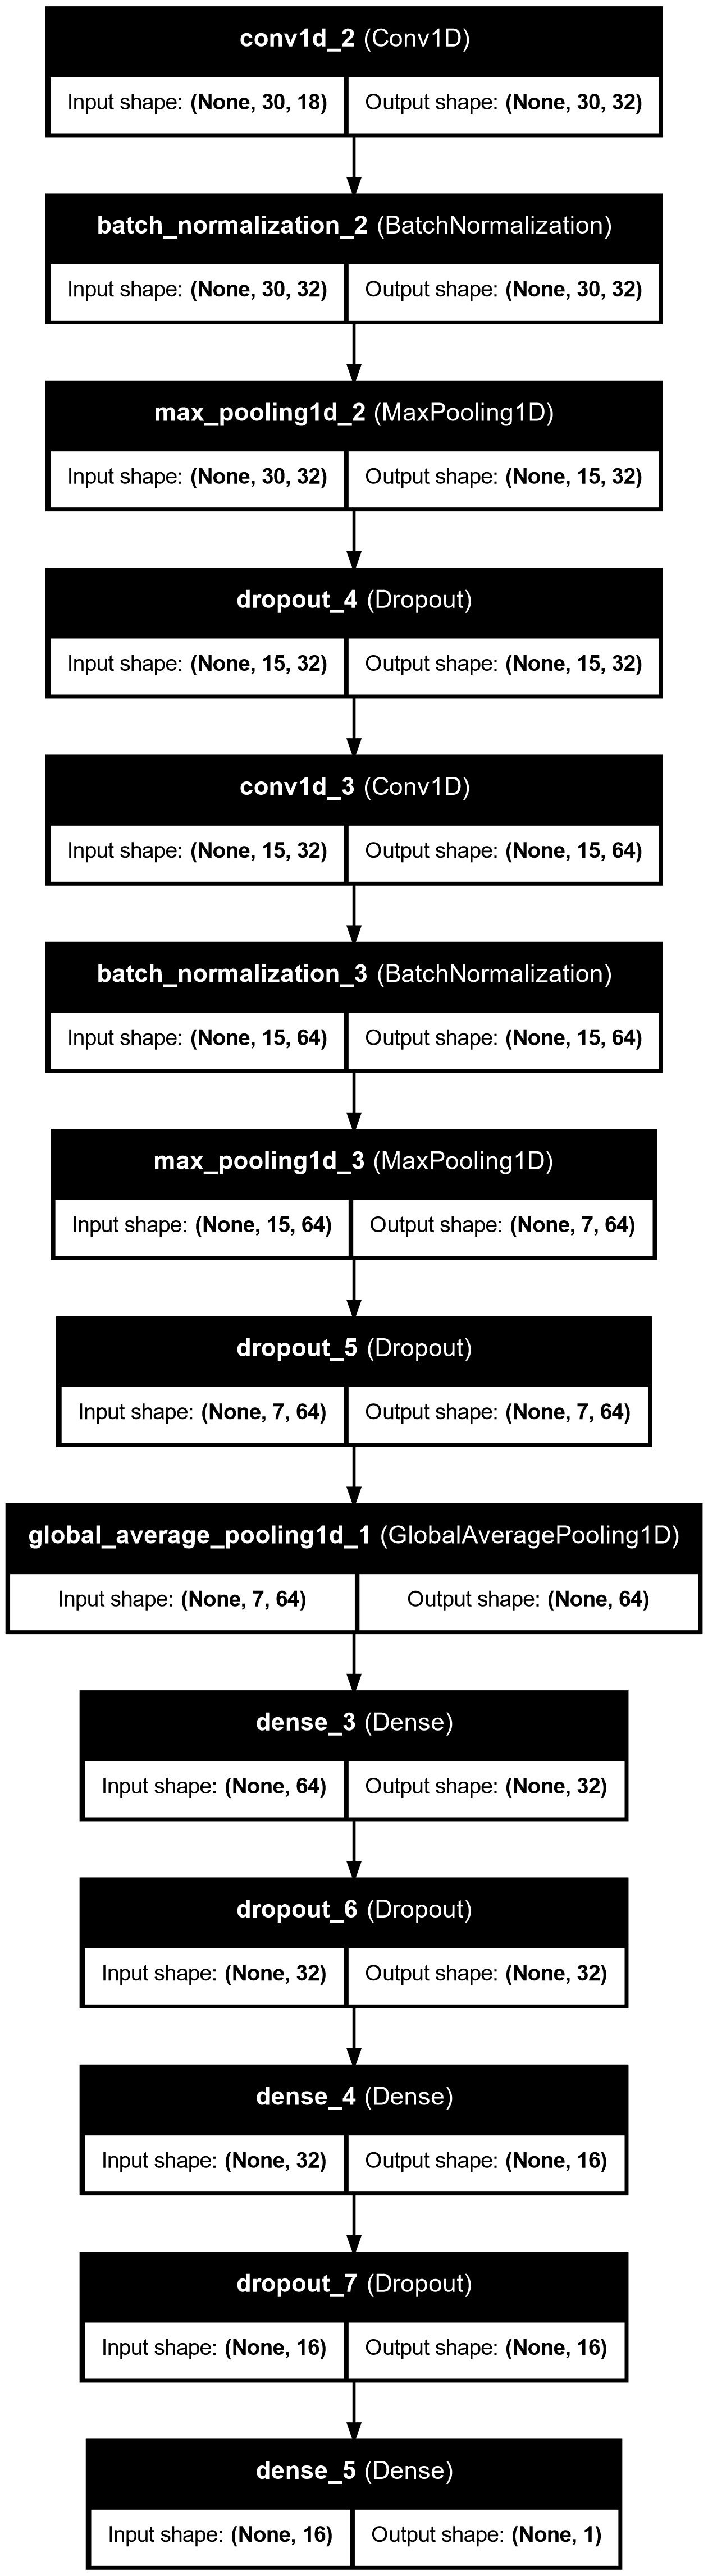

In [209]:
plot_model(baseline_model.model, to_file='model_architecture_cnn.png', show_shapes=True, show_layer_names=True)

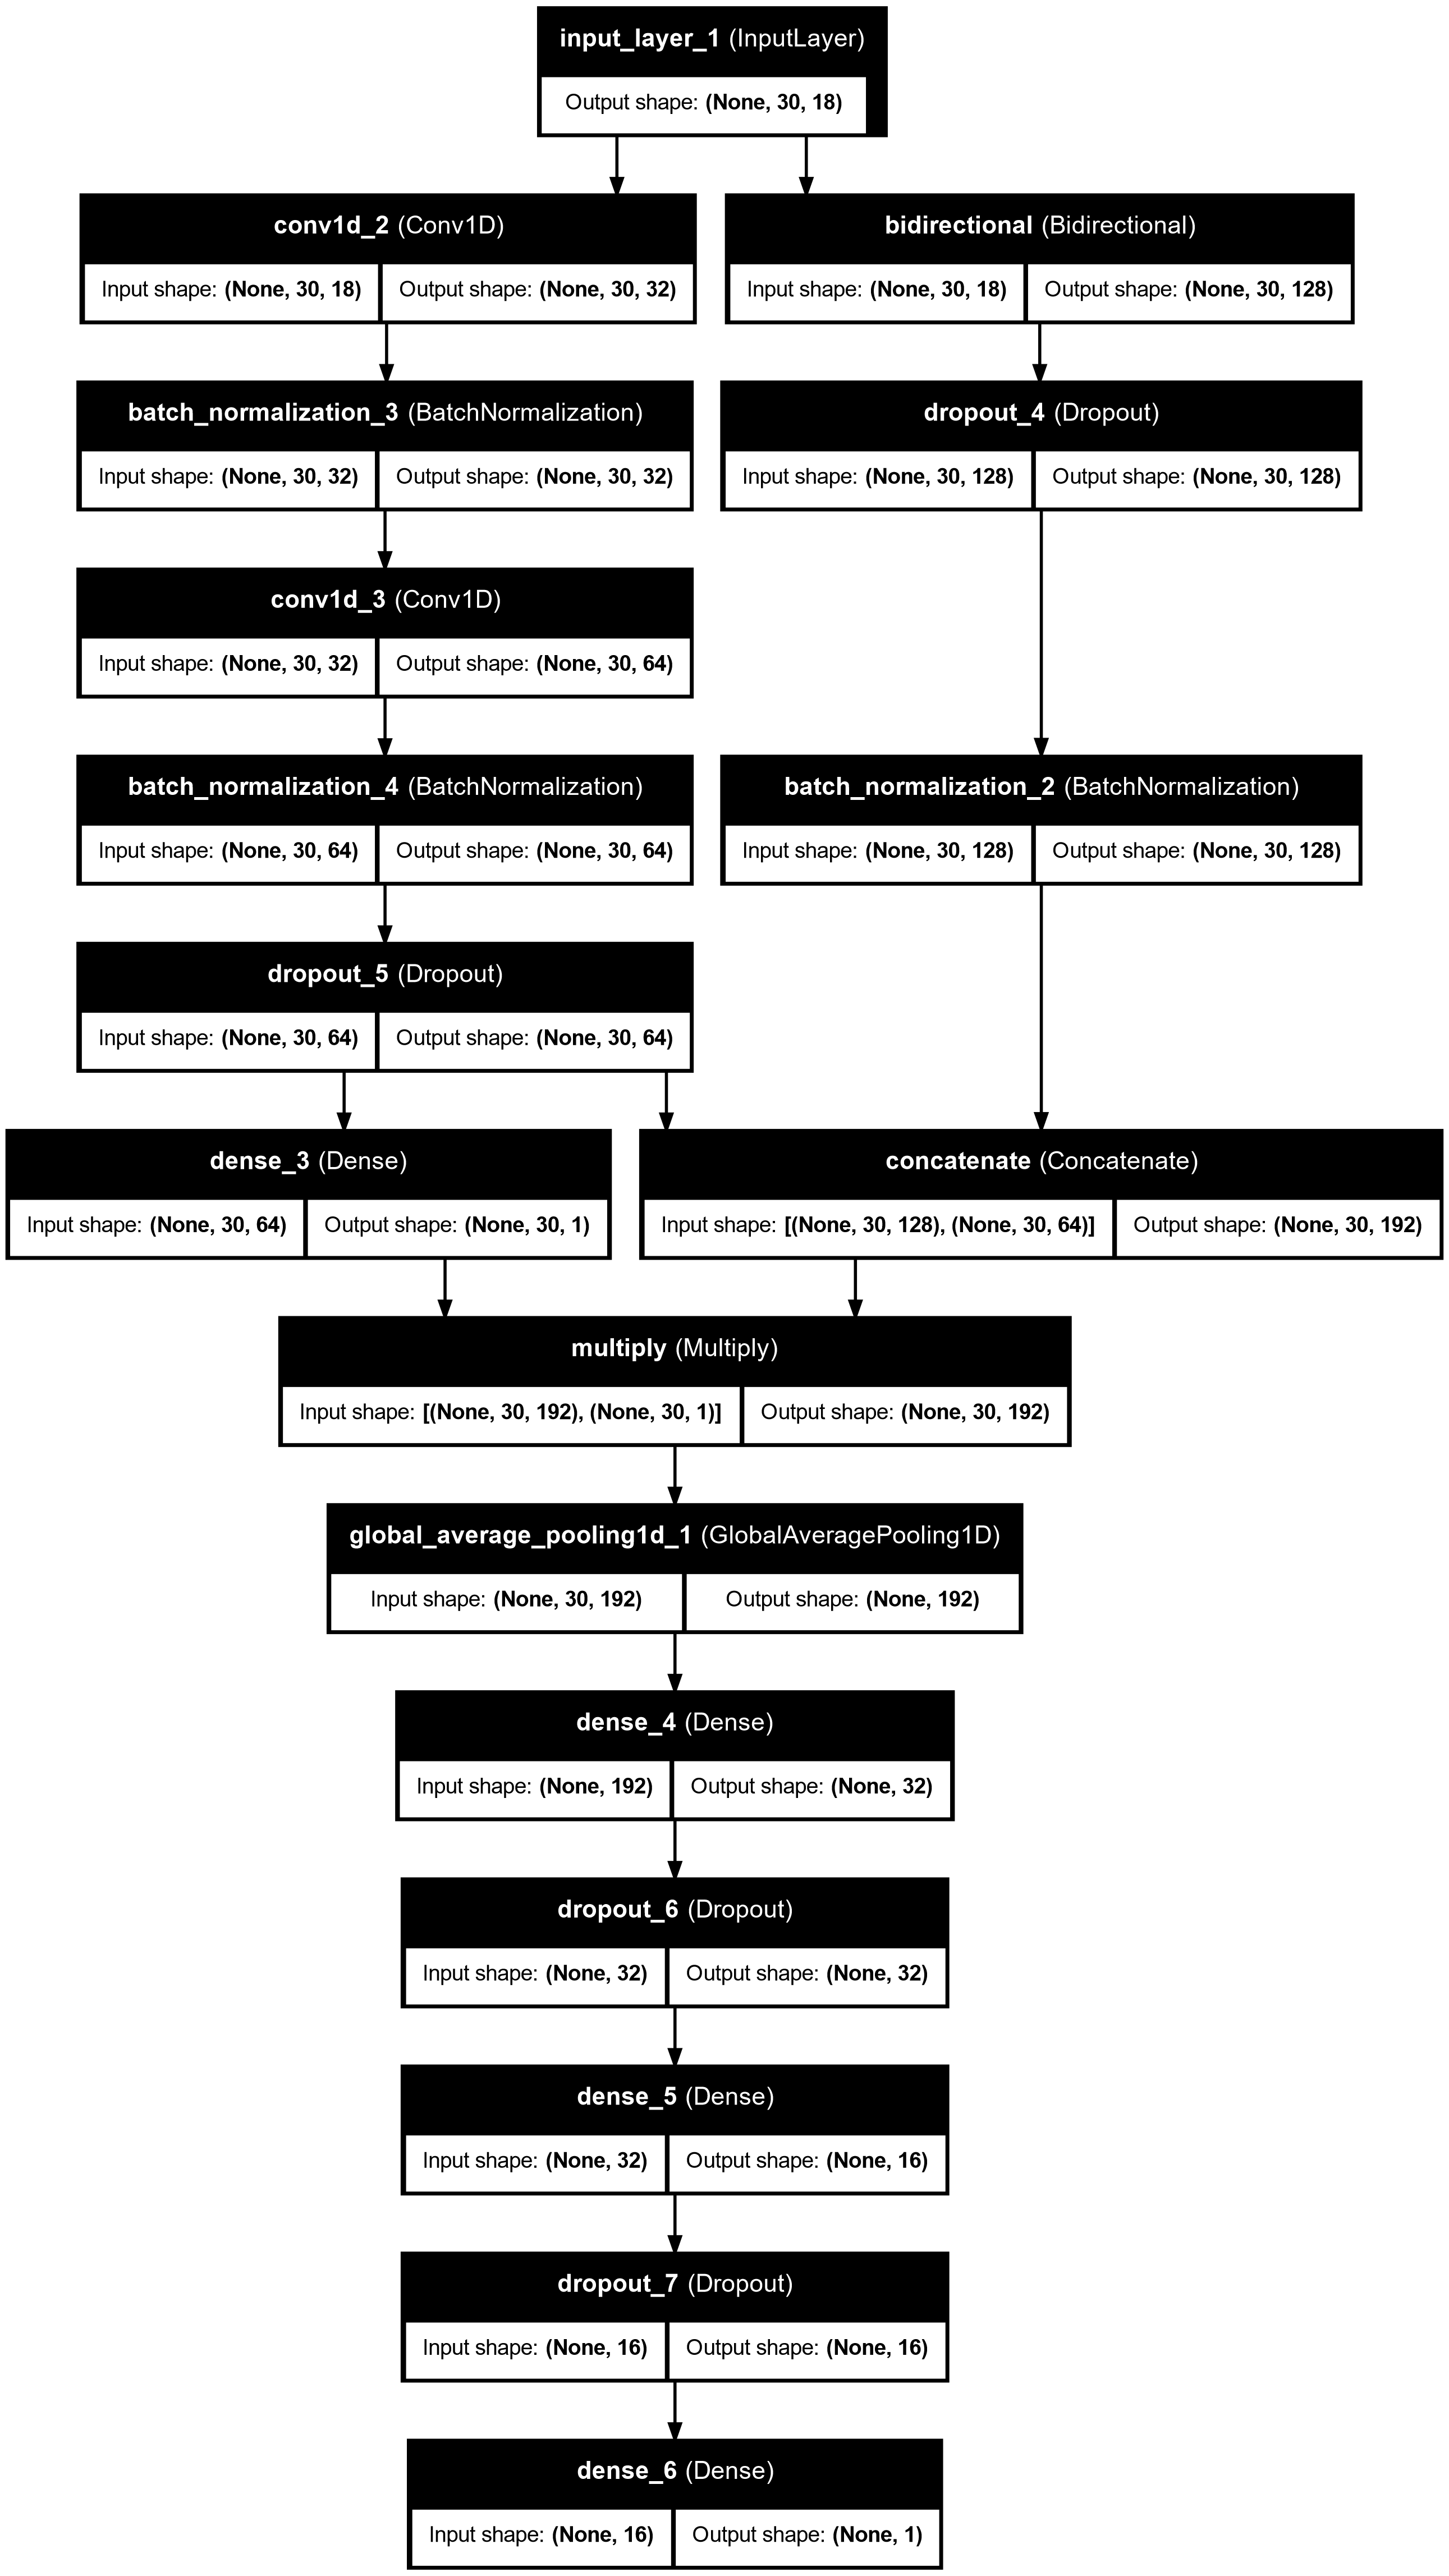

In [210]:
plot_model(improved_model.model, to_file='model_architecture_lstmcnn.png', show_shapes=True, show_layer_names=True)

### Model 1 - Baseline - CNN

Using the previous methods, the baseline model is evaluated and results plotted.

Baseline Model Evaluation...
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Baseline CNN Model Evaluation Metrics:
MAE: 20.49
MAE Naive Baseline: 2.94
SMAPE: 32.68%
MASE: 6.9777 (values < 1.0 indicate better than naive forecast)


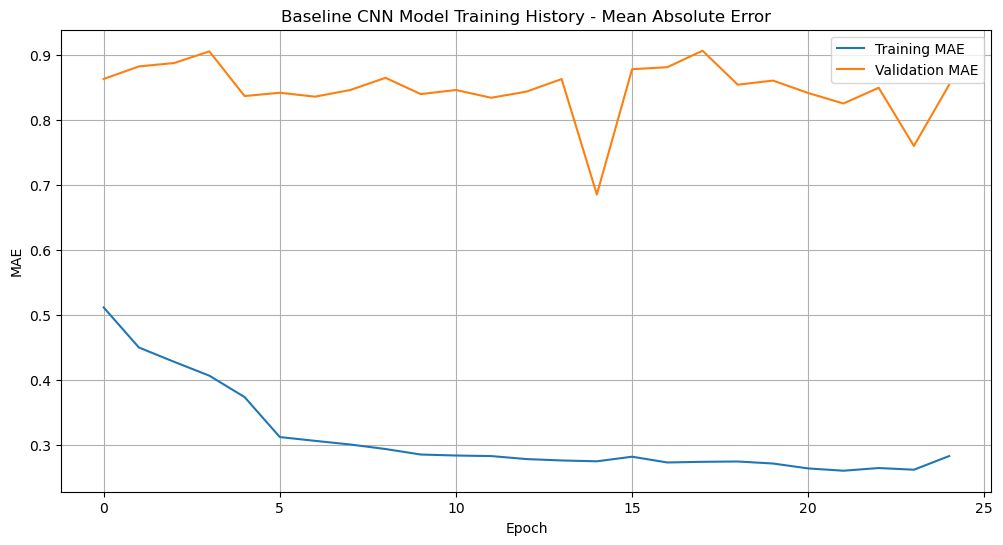

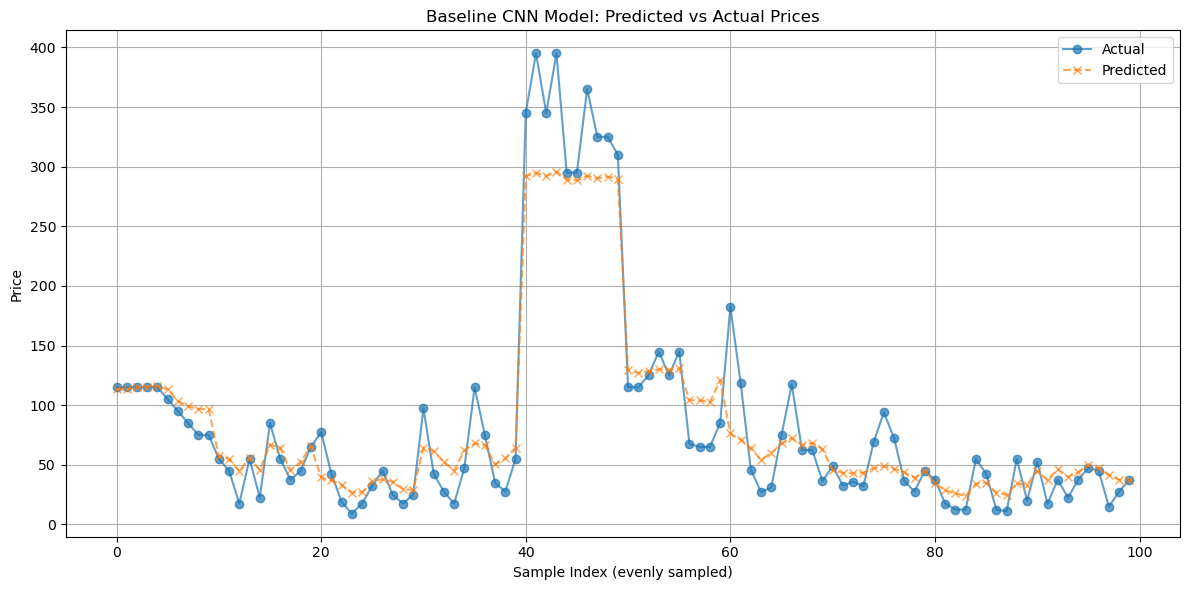

In [138]:
# Showing the evaluation of the baseline model
print("Baseline Model Evaluation...")
baseline_results = model_evaluation(baseline_model.model, X_test, y_test, preprocessor, commodities_test, model_name="Baseline CNN Model")
# Plotting the results of the baseline model
model_plot_results(baseline_history, baseline_results, model_name="Baseline CNN Model")

### Model 2 - Improved - LSTM-CNN

The same previous process is applied to the improved model to get and plot the metrics.

Improved Model Evaluation...
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Improved LSTM-CNN Model Evaluation Metrics:
MAE: 8.39
MAE Naive Baseline: 2.94
SMAPE: 11.62%
MASE: 2.8564 (values < 1.0 indicate better than naive forecast)


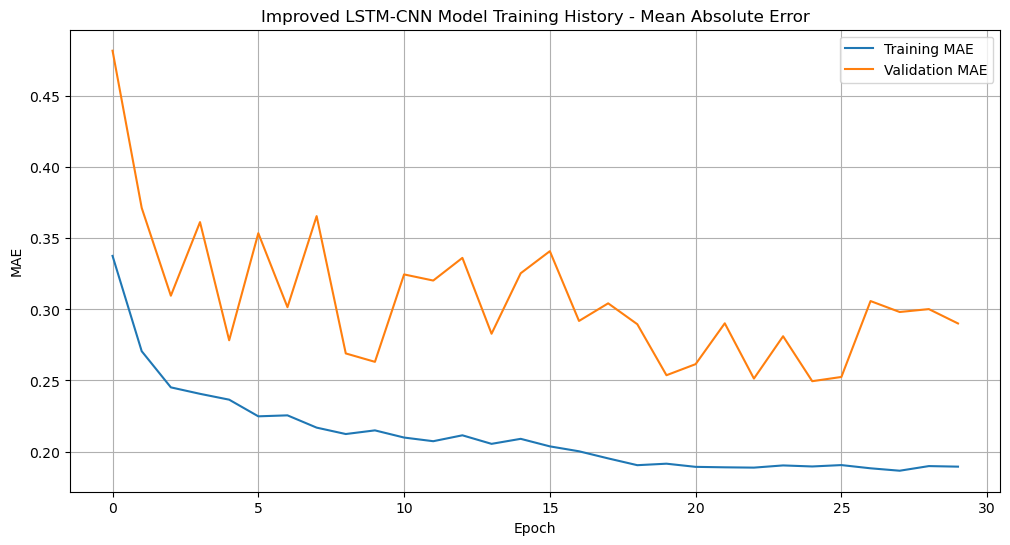

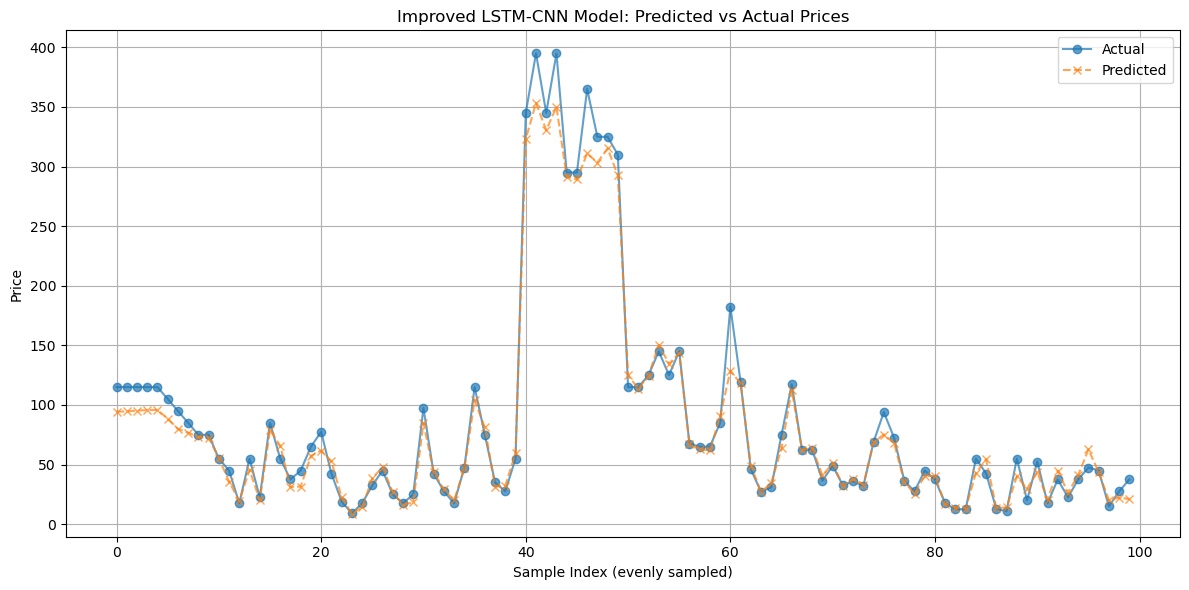

In [140]:
# Showing the evaluation of the improved model
print("Improved Model Evaluation...")
improved_results = model_evaluation(improved_model.model, X_test, y_test, preprocessor, commodities_test, model_name="Improved LSTM-CNN Model")
# Plotting the results of the baseline model
model_plot_results(improved_history, improved_results, model_name="Improved LSTM-CNN Model")

## 4. Hyperparameter Optimization.

### Bayesian Process Definition

Bayesian Optimization, implemented via BayesianOptimizer class, is the best choice  for the project. The expensive evaluation, because of the NN approach, fit with time series, and multiple interrelated hyperparameters, makes it the best choice. The class implements the following methods:
- _round_integer_params: round integer parameters.
- _objective_function: depending on the model evaluated, it set the parameters and gets the best validation MAE and returns the best parameters and score.
- _params_to_dict: converts parameters to dictionary to manage it later.
- _acquisition_function: evaluates the prediction and returns the result.
- optimize: main loop that performs the optimization process.

In [129]:
class BayesianOptimizer:
    """Bayesian optimization for hyperparameter tuning of regression models"""
    
    def __init__(self, model_class, param_bounds: Dict[str, Tuple[float, float]], 
                 integer_params: List[str] = None):
        self.model_class = model_class
        self.param_bounds = param_bounds
        self.param_names = list(param_bounds.keys())
        self.bounds = np.array(list(param_bounds.values()))
        self.integer_params = integer_params or []  # List of parameters that should be integers
        self.best_params = None
        self.best_score = float('inf')
        self.X_samples = []
        self.y_samples = []
        
        # Initialize Gaussian Process with Matern kernel
        kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, nu=2.5)
        self.gp = GaussianProcessRegressor(
            kernel=kernel, 
            n_restarts_optimizer=10,
            normalize_y=True  # Add normalization for numerical stability
        )
    
    def _round_integer_params(self, params: Dict[str, float]) -> Dict[str, Any]:
        """Round parameters that should be integers"""
        for param in self.integer_params:
            if param in params:
                params[param] = int(np.round(params[param]))
        return params
    
    def _objective_function(self, params_array: np.ndarray, X_train: np.ndarray, 
                          y_train: np.ndarray, X_val: np.ndarray, y_val: np.ndarray,
                          input_shape: Tuple[int, int]) -> float:
        """Objective function to minimize (validation MAE)"""
        try:
            # Convert parameters to dictionary and round integers
            params = self._params_to_dict(params_array)
            params = self._round_integer_params(params)
            
            # Build model based on class type
            model = self.model_class(input_shape=input_shape)
            
            if isinstance(model, LSTMCNNModel):
                model.build_model(
                    lstm_units=params['lstm_units'],
                    cnn_filters=params['cnn_filters'],
                    dropout_rate=params['dropout_rate'],
                    dense_units=params['dense_units'],
                    l2_reg=params['l2_reg']
                )
            else:  # CNNModel
                model.build_model(
                    filters1=params['filters1'],
                    filters2=params['filters2'],
                    dropout_rate=params['dropout_rate'],
                    dense_units=params['dense_units'],
                    l2_reg=params['l2_reg'],
                )
            
            # Compile and train
            model.compile_model(learning_rate=params['learning_rate'],
                                beta_1=params['beta_1'],
                                beta_2=params['beta_2'],
                                epsilon=params['epsilon'])
            history = model.train(
                X_train, y_train, X_val, y_val,
                epochs=30,  # Fixed epochs to reduce variability
                batch_size=params['batch_size']
            )
            
            # Get best validation MAE
            val_mae = min(history.history['val_mae'])
            
            # Clean up
            del model
            tf.keras.backend.clear_session()
            
            if np.isnan(val_mae) or np.isinf(val_mae):
                return float('inf')
                
            return float(val_mae)  # Ensure float type
            
        except Exception as e:
            print(f"Error in objective function: {e}")
            return float('inf')
        
    def _params_to_dict(self, params_array: np.ndarray) -> Dict[str, float]:
        """Convert parameters array to dictionary"""
        return {name: float(value) for name, value in zip(self.param_names, params_array)}
    
    def _acquisition_function(self, params_array: np.ndarray) -> float:
        """Expected Improvement acquisition function"""
        if params_array.ndim == 1:
            params_array = params_array.reshape(1, -1)
            
        mu, sigma = self.gp.predict(params_array, return_std=True)
        
        if sigma.ndim == 0 or sigma[0] == 0:
            return 0.0
            
        z = (self.best_score - mu) / sigma
        ei = (self.best_score - mu) * norm.cdf(z) + sigma * norm.pdf(z)
        return -float(ei[0])  # Return negative since we're minimizing
    
    def optimize(self, X_train: np.ndarray, y_train: np.ndarray, 
                X_val: np.ndarray, y_val: np.ndarray,
                input_shape: Tuple[int, int], n_iterations: int = 15,
                n_initial: int = 5) -> Dict[str, Any]:
        """Run Bayesian optimization"""
        try:
            # Initial random samples
            for _ in range(n_initial):
                params = np.random.uniform(
                    self.bounds[:, 0], self.bounds[:, 1], size=len(self.param_names)
                )
                score = self._objective_function(params, X_train, y_train, X_val, y_val, input_shape)
                
                if not np.isnan(score) and not np.isinf(score):
                    self.X_samples.append(params)
                    self.y_samples.append(score)
                    
                    if score < self.best_score:
                        self.best_score = score
                        self.best_params = self._round_integer_params(self._params_to_dict(params))
            
            # Main optimization loop
            for i in range(n_iterations):
                print(f"Iteration {i+1}/{n_iterations}")
                
                if len(self.X_samples) < 2:
                    print("Not enough valid samples to continue optimization")
                    break
                
                # Update Gaussian Process
                X_samples = np.array(self.X_samples)
                y_samples = np.array(self.y_samples)
                
                try:
                    self.gp.fit(X_samples, y_samples)
                except Exception as e:
                    print(f"Error fitting GP: {e}")
                    break
                
                # Find next point to evaluate
                result = minimize(
                    self._acquisition_function,
                    x0=X_samples[np.argmin(y_samples)],
                    bounds=self.bounds,
                    method='L-BFGS-B'
                )
                
                if not result.success:
                    print(f"Optimization failed: {result.message}")
                    continue
                
                # Evaluate new point
                new_params = result.x
                score = self._objective_function(new_params, X_train, y_train, X_val, y_val, input_shape)
                
                if not np.isnan(score) and not np.isinf(score):
                    self.X_samples.append(new_params)
                    self.y_samples.append(score)
                    
                    if score < self.best_score:
                        self.best_score = score
                        self.best_params = self._round_integer_params(self._params_to_dict(new_params))
                        print(f"New best score: {self.best_score:.4f}")
            
            return {
                'best_params': self.best_params,
                'best_score': self.best_score
            }
            
        except Exception as e:
            print(f"Error during optimization: {e}")
            if self.best_params is None:
                raise ValueError("Optimization failed to find valid parameters")
            return {
                'best_params': self.best_params,
                'best_score': self.best_score
            }

### Model 1 - Baseline - CNN

Using the previous class, runs the optimizer and shows the best result.

In [130]:
# Define parameter bounds for CNN model with integer casting for discrete parameters
cnn_param_bounds = {
    'filters1': (32, 128),          
    'filters2': (64, 256),          
    'dropout_rate': (0.1, 0.5),     
    'dense_units': (32, 128),       
    'learning_rate': (1e-4, 1e-2),  
    'batch_size': (16, 64),
    'l2_reg': (1e-5, 1e-3),
    'beta_1': (0.8, 0.99),
    'beta_2': (0.9, 0.999),
    'epsilon': (1e-8, 1e-6)     
}

# Specify which parameters should be integers
integer_params = ['filters1', 'filters2', 'dense_units', 'batch_size']

# Create and run CNN optimizer with error handling
try:
    print("Optimizing CNN Model...")
    # Clear previous models from memory
    tf.keras.backend.clear_session()

    # Initialize optimizer with integer parameters
    cnn_optimizer = BayesianOptimizer(
        model_class=CNNModel,
        param_bounds=cnn_param_bounds,
        integer_params=integer_params  # Add integer parameters list
    )

    # Run optimization
    cnn_results = cnn_optimizer.optimize(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        n_iterations=10,
        n_initial=3
    )

    # Print optimization results with formatted output
    print("\nBest CNN Model Parameters:")
    for param, value in cnn_results['best_params'].items():
        if param in ['filters1', 'filters2', 'dense_units', 'batch_size']:
            print(f"{param}: {int(value)}")
        else:
            print(f"{param}: {value:.6f}")
    print(f"Best CNN Model MAE: {cnn_results['best_score']:.4f}")

except Exception as e:
    print(f"Error during CNN optimization: {str(e)}")
    raise

finally:
    # Clean up memory
    tf.keras.backend.clear_session()

Optimizing CNN Model...
Epoch 1/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2563 - mae: 0.4375 - val_loss: 0.4755 - val_mae: 0.8387 - learning_rate: 0.0084
Epoch 2/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1194 - mae: 0.3242 - val_loss: 0.5425 - val_mae: 0.9232 - learning_rate: 0.0084
Epoch 3/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0991 - mae: 0.2937 - val_loss: 0.4742 - val_mae: 0.8475 - learning_rate: 0.0084
Epoch 4/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0962 - mae: 0.2940 - val_loss: 0.4644 - val_mae: 0.8345 - learning_rate: 0.0084
Epoch 5/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0865 - mae: 0.2804 - val_loss: 0.4633 - val_mae: 0.8353 - learning_rate: 0.0084
Epoch 6/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0992 - mae: 0.3001 - val_loss: 0.4748 - val_mae: 0.8500 - learning_rate: 0.0084
Epoch 7/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0903 - mae: 0.2840 - val_loss: 0.5018 - val_mae: 0.8821 - lear

A new model with the best metrics is trained to check its performance.

In [ ]:
print("Training Baseline Model (CNN) with tuned hyperparameters...")
baseline_model_opt = CNNModel(
    input_shape=(X_train.shape[1], X_train.shape[2])
)
# Buils the model with optimized parameters
baseline_model_opt.build_model(
    filters1=int(cnn_results['best_params']['filters1']),
    filters2=int(cnn_results['best_params']['filters2']),
    dropout_rate=cnn_results['best_params']['dropout_rate'],
    dense_units=int(cnn_results['best_params']['dense_units']),
    l2_reg=cnn_results['best_params']['l2_reg']
)
# Compile the model with optimized learning rate
baseline_model_opt.compile_model(learning_rate=cnn_results['best_params']['learning_rate'],
                                 beta_1=cnn_results['best_params']['beta_1'],
                                 beta_2=cnn_results['best_params']['beta_2'],
                                 epsilon=cnn_results['best_params']['epsilon'])
# Train the optimized baseline model
baseline_history_opt = baseline_model_opt.train(
    X_train, y_train, X_val, y_val, epochs=30, batch_size=int(cnn_results['best_params']['batch_size']))

# Last best parameters for reference
# filters1=75, filters2=229, dropout_rate=0.499881, dense_units=125, learning_rate=0.000018, 
# beta_1=0.825750, beta_2=0.998878, epsilon=0.000001, batch_size=63
# baseline_model_opt.build_model(filters1=75, filters2=229, dropout_rate=0.499881, dense_units=125)
# baseline_model_opt.compile_model(learning_rate=0.000018, beta_1=0.825750, beta_2=0.998878, epsilon=0.000001)
# baseline_history_opt = baseline_model_opt.train(X_train, y_train, X_val, y_val, epochs=30, batch_size=63)

print("Training process completed.")

Training Baseline Model (CNN) with tuned hyperparameters...
Epoch 1/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.4079 - mae: 0.7539 - val_loss: 0.3491 - val_mae: 0.6928 - learning_rate: 1.4306e-04
Epoch 2/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2206 - mae: 0.5213 - val_loss: 0.3518 - val_mae: 0.6789 - learning_rate: 1.4306e-04
Epoch 3/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1801 - mae: 0.4595 - val_loss: 0.2768 - val_mae: 0.5829 - learning_rate: 1.4306e-04
Epoch 4/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1586 - mae: 0.4273 - val_loss: 0.2547 - val_mae: 0.5529 - learning_rate: 1.4306e-04
Epoch 5/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1425 - mae: 0.4015 - val_loss: 0.2341 - val_mae: 0.5194 - learning_rate: 1.4306e-04
Epoch 6/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1379 - mae: 0.3927 - val_loss: 0.2243 - val_mae: 0.5061 - learning_rate: 1.4306e-04
Epoch 7/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.13

The performance of the optimized model is checked.

Baseline Model Optimized Evaluation...
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Baseline CNN Model Optimized Evaluation Metrics:
MAE: 15.08
MAE Naive Baseline: 2.94
SMAPE: 21.52%
MASE: 5.1365 (values < 1.0 indicate better than naive forecast)


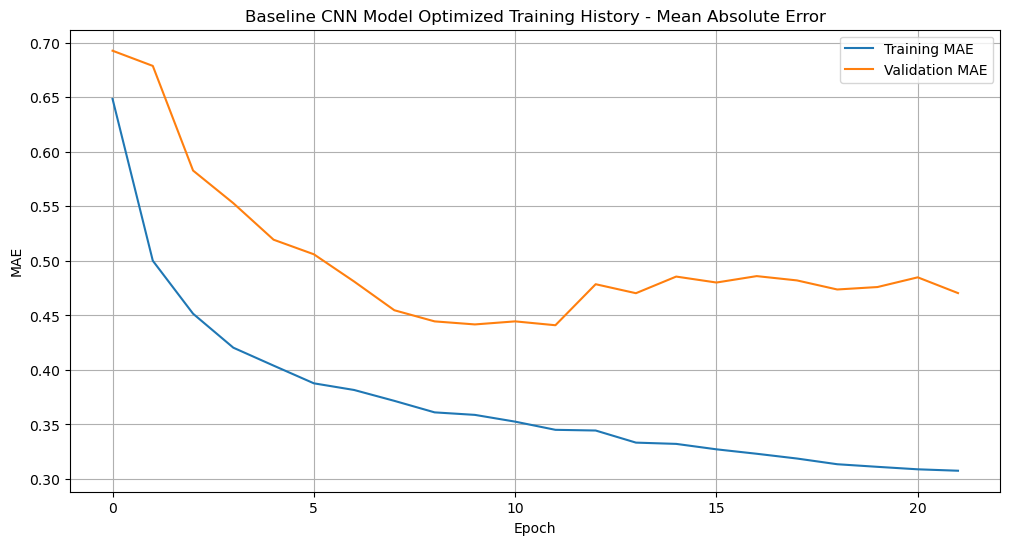

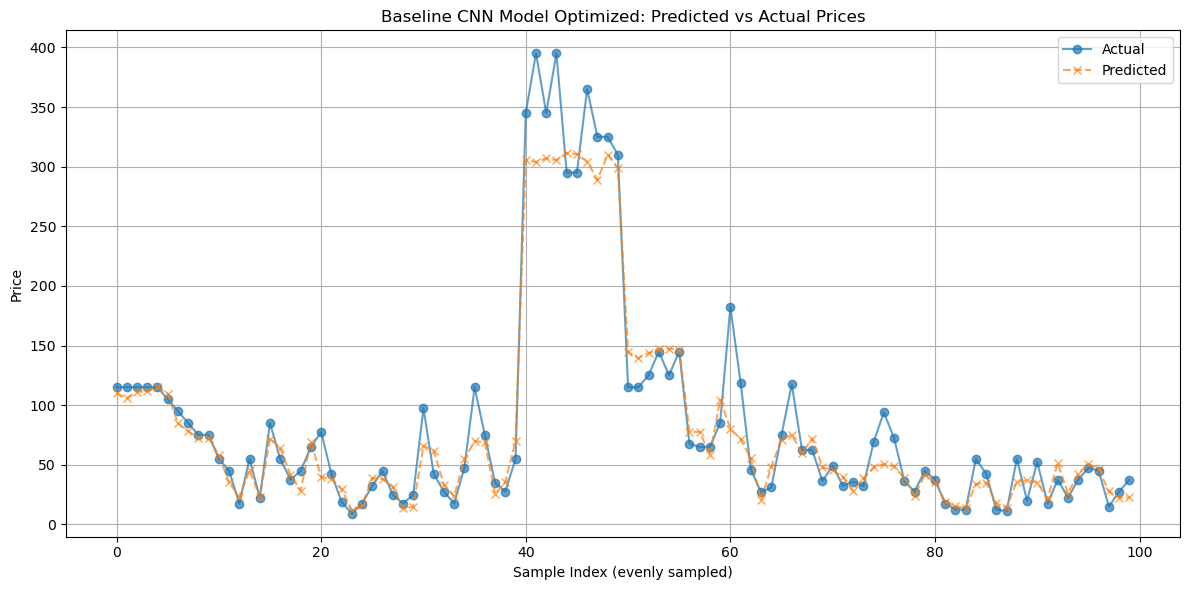

In [139]:
# Showing the evaluation of the baseline model
print("Baseline Model Optimized Evaluation...")
baseline_results_opt = model_evaluation(baseline_model_opt.model, X_test, y_test, preprocessor, commodities_test, model_name="Baseline CNN Model Optimized")
# Plotting the results of the baseline model
model_plot_results(baseline_history_opt, baseline_results_opt, model_name="Baseline CNN Model Optimized")

### Model 2 - Improved - LSTM-CNN

Performs the same process with the improved model.

In [144]:
# Define parameter bounds for LSTM-CNN model with integer casting for discrete parameters
lstm_cnn_param_bounds = {
    'lstm_units': (32, 128),        # Integer
    'cnn_filters': (16, 64),        # Integer
    'dropout_rate': (0.1, 0.5),     # Float
    'dense_units': (32, 128),       # Integer
    'learning_rate': (1e-4, 1e-2),  # Float
    'batch_size': (16, 64),         # Integer
    'l2_reg': (1e-5, 1e-3),          # Float
    'beta_1': (0.8, 0.99),          # Float
    'beta_2': (0.9, 0.999),         # Float
    'epsilon': (1e-8, 1e-6)          # Float
}

# Specify which parameters should be integers
integer_params = ['lstm_units', 'cnn_filters', 'dense_units', 'batch_size']

# Create and run LSTM-CNN optimizer with error handling and memory management
try:
    print("\nOptimizing LSTM-CNN Model...")
    # Clear previous model from memory
    tf.keras.backend.clear_session()

    # Initialize optimizer with integer parameters
    lstm_cnn_optimizer = BayesianOptimizer(
        model_class=LSTMCNNModel,
        param_bounds=lstm_cnn_param_bounds,
        integer_params=integer_params  # Add integer parameters list
    )

    # Run optimization
    lstm_cnn_results = lstm_cnn_optimizer.optimize(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        n_iterations=10,
        n_initial=3
    )

    # Print optimization results with formatted output
    print("\nBest LSTM-CNN Model Parameters:")
    for param, value in lstm_cnn_results['best_params'].items():
        if param in ['lstm_units', 'cnn_filters', 'dense_units', 'batch_size']:
            print(f"{param}: {int(value)}")
        else:
            print(f"{param}: {value:.6f}")
    print(f"Best LSTM-CNN Model MAE: {lstm_cnn_results['best_score']:.4f}")

except Exception as e:
    print(f"Error during LSTM-CNN optimization: {str(e)}")
    raise

finally:
    # Clean up memory
    tf.keras.backend.clear_session()


Optimizing LSTM-CNN Model...
Epoch 1/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.2361 - mae: 0.3824 - val_loss: 0.1048 - val_mae: 0.2873 - learning_rate: 0.0088
Epoch 2/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0844 - mae: 0.2622 - val_loss: 0.0872 - val_mae: 0.2584 - learning_rate: 0.0088
Epoch 3/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0729 - mae: 0.2445 - val_loss: 0.0928 - val_mae: 0.2880 - learning_rate: 0.0088
Epoch 4/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0701 - mae: 0.2423 - val_loss: 0.1084 - val_mae: 0.3057 - learning_rate: 0.0088
Epoch 5/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0678 - mae: 0.2379 - val_loss: 0.0891 - val_mae: 0.2720 - learning_rate: 0.0088
Epoch 6/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0662 - mae: 0.2376 - val_loss: 0.1006 - val_mae: 0.2920 - learning_rate: 0.0088
Epoch 7/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0658 - mae: 0.2365 - val_loss: 0.1189 - val_mae:

Similar as the previous model, a new model is trained using the best parameters

In [146]:
print("Training Improved Model (LSTM-CNN Hybrid) with tuned hyperparameters...")
improved_model_opt = LSTMCNNModel(
    input_shape=(X_train.shape[1], X_train.shape[2]) 
)

# BUild the model with optimized parameters
improved_model_opt.build_model(
    lstm_units=int(lstm_cnn_results['best_params']['lstm_units']),
    cnn_filters=int(lstm_cnn_results['best_params']['cnn_filters']),
    dropout_rate=lstm_cnn_results['best_params']['dropout_rate'],
    dense_units=int(lstm_cnn_results['best_params']['dense_units']),
    l2_reg=lstm_cnn_results['best_params']['l2_reg']
)
# Compile the model with optimized learning rate
improved_model_opt.compile_model(learning_rate=lstm_cnn_results['best_params']['learning_rate'],
                                 beta_1=lstm_cnn_results['best_params']['beta_1'],
                                 beta_2=lstm_cnn_results['best_params']['beta_2'],
                                 epsilon=lstm_cnn_results['best_params']['epsilon'])
# Train the optimized improved model
improved_history_opt = improved_model_opt.train(
    X_train, y_train, X_val, y_val, epochs=30, batch_size=int(lstm_cnn_results['best_params']['batch_size'])
)

# Last best parameters for reference
# lstm_units: 91, cnn_filters: 35, dropout_rate: 0.149221, dense_units: 61, l2_reg: 0.000585
# learning_rate: 0.008844, beta_1: 0.850842, beta_2: 0.954264, epsilon: 0.000001 
# batch_size: 22
# Build the model with optimized parameters
# improved_model_opt.build_model(lstm_units=91, cnn_filters=35, dropout_rate=0.149221, dense_units=61, l2_reg=0.000585)
# improved_model_opt.compile_model(learning_rate=0.008844, beta_1=0.850842, beta_2=0.954264, epsilon=0.000001)
# improved_history_opt = improved_model_opt.train(X_train, y_train, X_val, y_val, epochs=30, batch_size=22)

print("Training process completed.")

Training Improved Model (LSTM-CNN Hybrid) with tuned hyperparameters...
Epoch 1/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 0.2376 - mae: 0.3886 - val_loss: 0.1167 - val_mae: 0.3214 - learning_rate: 0.0088
Epoch 2/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0889 - mae: 0.2790 - val_loss: 0.1041 - val_mae: 0.3050 - learning_rate: 0.0088
Epoch 3/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0805 - mae: 0.2663 - val_loss: 0.1254 - val_mae: 0.3321 - learning_rate: 0.0088
Epoch 4/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0791 - mae: 0.2677 - val_loss: 0.0971 - val_mae: 0.2822 - learning_rate: 0.0088
Epoch 5/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0728 - mae: 0.2557 - val_loss: 0.0925 - val_mae: 0.2772 - learning_rate: 0.0088
Epoch 6/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0755 - mae: 0.2637 - val_loss: 0.1089 - val_mae: 0.3066 - learning_rate: 0.0088
Epoch 7/30
741/741 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0720 -

The performance of the optimized model is checked.

Improved and optimized Model Evaluation...
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Improved LSTM-CNN Model Optimized Evaluation Metrics:
MAE: 8.80
MAE Naive Baseline: 2.94
SMAPE: 12.07%
MASE: 2.9983 (values < 1.0 indicate better than naive forecast)


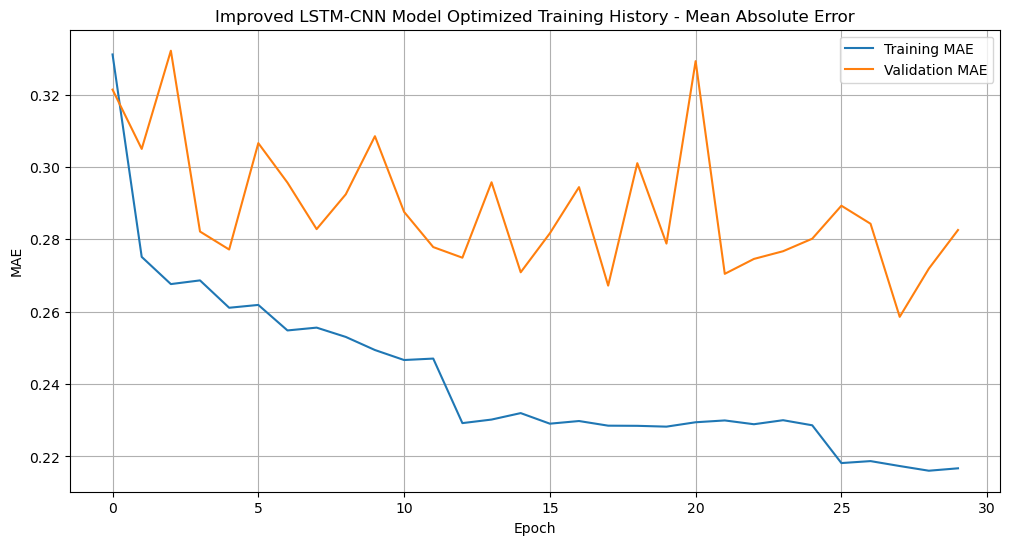

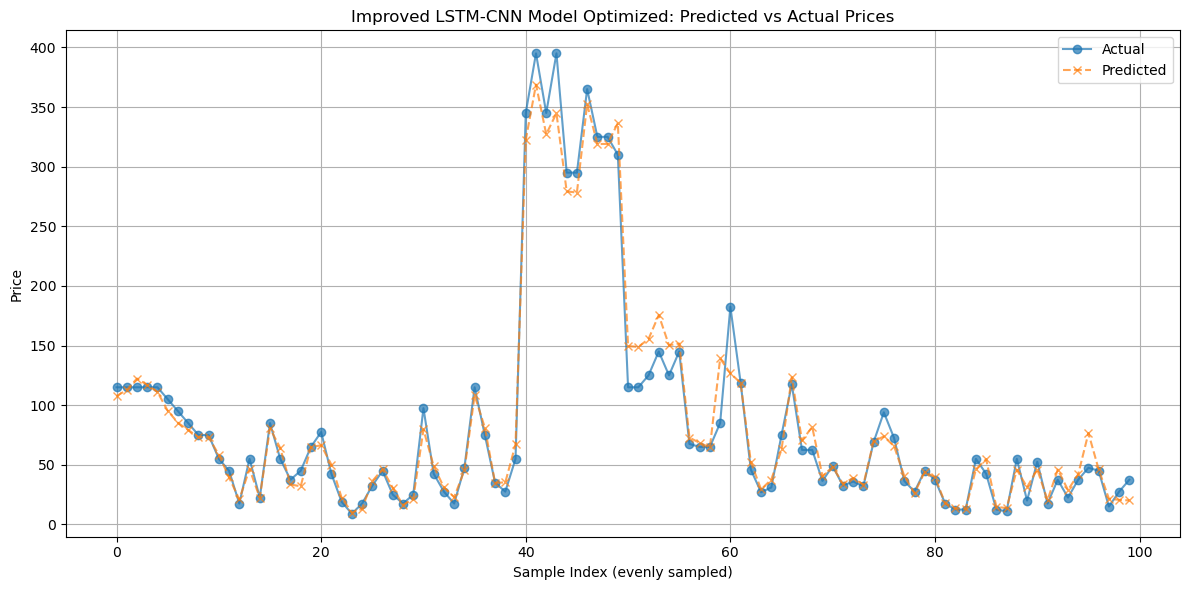

In [148]:
# Showing the evaluation of the improved model
print("Improved and optimized Model Evaluation...")
improved_results_opt = model_evaluation(improved_model_opt.model, X_test, y_test, preprocessor, commodities_test, model_name="Improved LSTM-CNN Model Optimized")
# Plotting the results of the baseline model
model_plot_results(improved_history_opt, improved_results_opt, model_name="Improved LSTM-CNN Model Optimized")

## 5. Explainability.

### SHAP definition

SHAP values is the best option for the models defined, specifically, Gradient Explainer approach. It has good performance with deep learning, times series, and non-linear relationships. The class DeepTimeSeriesExplainer implements the process using the following methods (note: the real_values suffix is to clarify that the process works with the real values instead of the normalized):
- explain_predictions_real_values: calculates SHAP values and feature importance. 
- plot_feature_importance_real: plot feature importance using the calculations.
- plot_shap_summary_real: plot SHAP summary plot.
- plot_force_plot_real: plot SHAP force plot
- get_prediction_explanation_real: get information about the prediction to show later.

In [ ]:
class DeepTimeSeriesExplainer:
    """Enhanced explainability with real (denormalized) values"""
    
    def __init__(self, model: keras.Model, preprocessor: TimeSeriesPreprocessor):
        self.model = model
        self.preprocessor = preprocessor
        
    def explain_predictions_real_values(self, X: np.ndarray, y: np.ndarray, commodities: np.ndarray, 
                                  feature_names: List[str] = None,
                                  n_samples: int = 100) -> Dict[str, np.ndarray]:
        """Generate SHAP values using real (denormalized) feature values"""
        try:
            # Get subset for analysis
            X_subset = X[:min(n_samples, len(X))]
            y_subset = y[:min(n_samples, len(y))]
            commodities_subset = commodities[:min(n_samples, len(commodities))]
            
            # First, get SHAP values using the normalized data (standard approach)
            background = tf.convert_to_tensor(X_subset, dtype=tf.float32)
            explainer = shap.GradientExplainer(
                model=self.model,
                data=background
            )
            
            # Calculate SHAP values with normalized data
            shap_values_normalized = explainer.shap_values(X_subset)
            
            # Handle different types of SHAP value outputs
            if isinstance(shap_values_normalized, list):
                shap_values_normalized = shap_values_normalized[0]
            
            if shap_values_normalized.ndim == 4:
                shap_values_normalized = shap_values_normalized.squeeze(-1)
            
            # Now denormalize the features for display purposes
            X_real = self.preprocessor.inverse_transform_X(X_subset, commodities_subset)
            
            # Denormalize the target values
            y_real = self.preprocessor.inverse_transform_y(y_subset, commodities_subset)
            
            # Get model predictions and denormalize them
            y_pred_normalized = self.model.predict(X_subset, verbose=0).flatten()
            y_pred_real = self.preprocessor.inverse_transform_y(y_pred_normalized, commodities_subset)
            
            # Calculate feature importance
            feature_importance = np.abs(shap_values_normalized).mean(axis=(0, 1))
            
            if feature_names is None:
                feature_names = [f'Feature_{i}' for i in range(len(feature_importance))]
            
            # Store for later use
            self.explainer = explainer
            self.X_real = X_real
            self.X_normalized = X_subset
            self.y_real = y_real
            self.y_pred_real = y_pred_real
                
            return {
                'shap_values': shap_values_normalized,  # SHAP values in normalized scale
                'feature_importance': feature_importance,
                'feature_names': feature_names,
                'X_real': X_real,  # Real feature values for display
                'X_normalized': X_subset,  # Normalized values used for SHAP
                'y_real': y_real,  # Real target values
                'y_pred_real': y_pred_real  # Real predicted values
            }
        
        except Exception as e:
            print(f"Error in explain_predictions_real_values: {str(e)}")
            raise
    
    def plot_feature_importance_real(self, explanation: Dict[str, np.ndarray]):
        """Plot feature importance with real values context"""
        try:
            plt.figure(figsize=(14, 8))
            importance = explanation['feature_importance']
            names = explanation['feature_names']
            X_real = explanation['X_real']
            
            # Ensure importance values are 1D
            if importance.ndim > 1:
                importance = importance.mean(axis=tuple(range(importance.ndim-1)))
            
            # Check if lengths match
            if len(importance) != len(names):
                min_len = min(len(importance), len(names))
                importance = importance[:min_len]
                names = names[:min_len]
            
            # Sort features by importance
            indices = np.argsort(importance)
            
            # Create bar plot
            y_pos = np.arange(len(importance))
            bars = plt.barh(y_pos, importance[indices])
            plt.yticks(y_pos, [names[i] for i in indices])
            
            # Add feature value ranges and statistics as text (rounded to 4 decimals)
            for i, (bar, idx) in enumerate(zip(bars, indices)):
                if X_real.ndim == 3:
                    feature_values = X_real[:, :, idx].flatten()
                else:
                    feature_values = X_real[:, idx]
                
                min_val = np.round(np.min(feature_values), 4)
                max_val = np.round(np.max(feature_values), 4)
                mean_val = np.round(np.mean(feature_values), 4)
            
            plt.title('Feature Importance (SHAP values) - With Real Value Statistics')
            plt.xlabel('Mean |SHAP value| (normalized scale)')
            plt.subplots_adjust(right=0.75)  # Make room for the text
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error in plot_feature_importance_real: {str(e)}")
            raise
    
    def plot_shap_summary_real(self, explanation: Dict[str, np.ndarray], max_display: int = 10):
        """Plot SHAP summary plot using real feature values"""
        try:
            # Get SHAP values and real feature values
            shap_values = explanation['shap_values']
            X_real = explanation['X_real']
            feature_names = explanation['feature_names']
            
            # Reshape SHAP values if needed
            if shap_values.ndim > 2:
                if shap_values.ndim == 4:
                    shap_values = shap_values.squeeze(-1)  # Remove last dimension if it's 1
                if shap_values.ndim == 3:
                    shap_values = shap_values.mean(axis=1)  # Average over sequence dimension
            
            # Reshape real feature values if needed
            if X_real.ndim > 2:
                if X_real.ndim == 3:
                    X_real_2d = X_real.mean(axis=1)  # Average over sequence dimension
                else:
                    X_real_2d = X_real
            else:
                X_real_2d = X_real
            
            # Round values to 4 decimals for better readability
            shap_values_rounded = np.round(shap_values, 4)
            X_real_rounded = np.round(X_real_2d, 4)
            
            # Ensure we have the right number of features
            n_features = min(len(feature_names), shap_values_rounded.shape[1], X_real_rounded.shape[1])
            
            # Truncate if necessary
            shap_values_plot = shap_values_rounded[:, :n_features]
            X_real_plot = X_real_rounded[:, :n_features]
            feature_names_plot = feature_names[:n_features]
            
            print(f"Creating SHAP summary plot with real values")
            print(f"SHAP values shape: {shap_values_plot.shape}")
            print(f"Real features shape: {X_real_plot.shape}")
            print(f"Number of features: {len(feature_names_plot)}")
            
            # Create summary plot
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_values_plot,
                X_real_plot,
                feature_names=feature_names_plot,
                max_display=max_display,
                show=False,
                plot_size=(10, 6)
            )
            plt.title('SHAP Summary Plot (Real Feature Values)')
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error in plot_shap_summary_real: {str(e)}")
            print(f"SHAP values shape: {shap_values.shape}")
            print(f"X_real shape: {X_real.shape}")
            print(f"Number of feature names: {len(feature_names)}")
            raise

    def plot_force_plot_real(self, explanation: Dict[str, np.ndarray], 
                       sample_idx: int = 0, matplotlib: bool = True, **kwargs):
        """Plot force plot using real feature values for display"""
        try:
            if not hasattr(self, 'explainer'):
                raise ValueError("Explainer not found. Please run explain_predictions_real_values() first.")
            
            shap_values = explanation['shap_values']
            feature_names = explanation['feature_names']
            X_real = explanation['X_real']
            X_normalized = explanation['X_normalized']
            y_real = explanation['y_real']
            y_pred_real = explanation['y_pred_real']
            
            # Reshape if needed
            if shap_values.ndim > 2:
                if shap_values.ndim == 4:
                    shap_values = shap_values.squeeze(-1)
                if shap_values.ndim == 3:
                    shap_values = shap_values.mean(axis=1)
            
            if X_real.ndim > 2:
                if X_real.ndim == 3:
                    X_real_2d = X_real.mean(axis=1)  # Average over sequence
                else:
                    X_real_2d = X_real
            else:
                X_real_2d = X_real
            
            # Get expected value using normalized data (as the model expects)
            predictions = self.model.predict(X_normalized, verbose=0)
            if predictions.ndim > 1:
                predictions = predictions.squeeze()
            expected_value = np.mean(predictions)
            
            # print(f"Creating force plot with real values for sample {sample_idx}")
            
            # Create force plot using real feature values for display
            force_plot = shap.force_plot(
                base_value=expected_value,
                shap_values=shap_values[sample_idx],
                features=np.round(X_real_2d[sample_idx], 4),  # Round real values to 4 decimals
                feature_names=feature_names,
                show=False,
                matplotlib=matplotlib,
                **kwargs
            )
            
            if matplotlib:
                plt.title(f'SHAP Force Plot - Sample {sample_idx} (Real Values)\nActual: {np.round(y_real[sample_idx], 4)}, Predicted: {np.round(y_pred_real[sample_idx], 4)}')
                plt.tight_layout()
                plt.show()
            else:
                return force_plot
                
        except Exception as e:
            print(f"Error in plot_force_plot_real: {str(e)}")
            raise
    
    def get_prediction_explanation_real(self, explanation: Dict[str, np.ndarray], 
                                   sample_idx: int = 0) -> Dict[str, any]:
        """Get detailed explanation with real feature values"""
        try:
            shap_values = explanation['shap_values']
            feature_names = explanation['feature_names']
            X_real = explanation['X_real']
            X_normalized = explanation['X_normalized']
            y_real = explanation['y_real']
            y_pred_real = explanation['y_pred_real']
            
            # Reshape if needed
            if shap_values.ndim > 2:
                if shap_values.ndim == 4:
                    shap_values = shap_values.squeeze(-1)
                if shap_values.ndim == 3:
                    shap_values = shap_values.mean(axis=1)
            
            if X_real.ndim > 2:
                X_real_2d = X_real.mean(axis=1)
            else:
                X_real_2d = X_real
            
            # Get prediction
            prediction = self.model.predict(X_normalized[sample_idx:sample_idx+1], verbose=0)[0]
            if prediction.ndim > 0:
                prediction = prediction[0]
            
            # Get SHAP contributions for this sample
            sample_shap = shap_values[sample_idx]
            sample_features_real = X_real_2d[sample_idx]
            
            # Create feature contribution summary with real values (rounded to 4 decimals)
            contributions = []
            for i, (name, shap_val, real_val) in enumerate(zip(feature_names, sample_shap, sample_features_real)):
                contributions.append({
                    'feature': name,
                    'real_value': round(float(real_val), 4),
                    'shap_value': round(float(shap_val), 4),
                    'abs_shap_value': round(float(abs(shap_val)), 4),
                    'contribution_type': 'positive' if shap_val > 0 else 'negative'
                })
            
            # Sort by absolute SHAP value
            contributions.sort(key=lambda x: x['abs_shap_value'], reverse=True)
            
            return {
                'sample_idx': sample_idx,
                'actual_target': round(float(y_real[sample_idx]), 4),
                'predicted_target': round(float(y_pred_real[sample_idx]), 4),
                'prediction_error': round(float(abs(y_real[sample_idx] - y_pred_real[sample_idx])), 4),
                'prediction': round(float(prediction), 4),
                'base_value': round(float(np.mean(self.model.predict(X_normalized, verbose=0))), 4),
                'total_shap_contribution': round(float(np.sum(sample_shap)), 4),
                'top_positive_features': [c for c in contributions if c['contribution_type'] == 'positive'][:5],
                'top_negative_features': [c for c in contributions if c['contribution_type'] == 'negative'][:5],
                'all_contributions': contributions
            }
            
        except Exception as e:
            print(f"Error in get_prediction_explanation_real: {str(e)}")
            raise

Feature list is defined to send it to the process. These are the features to calculate the SHAP values.

In [197]:
# Get the actual feature names from the preprocessor
feature_names = preprocessor.get_feature_importance_names()
print(f"Actual features used by the model: {feature_names}")
print(f"Number of features: {len(feature_names)}")
# Initializing Javascript to visualize values
shap.initjs()

Actual features used by the model: ['Minimum', 'Maximum', 'year', 'day', 'month', 'day_of_week', 'price_change', 'price_change_7d', 'price_acceleration', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'dayofweek_sin', 'dayofweek_cos', 'price_range', 'price_range_ratio', 'price_position']
Number of features: 18


### Model 1 - Baseline - CNN

Feature importance and summarize plot are shown in this section.


CNN Model Explanations with Real Values:
SHAP values shape: (100, 30, 18)
Real feature values shape: (100, 30, 18)


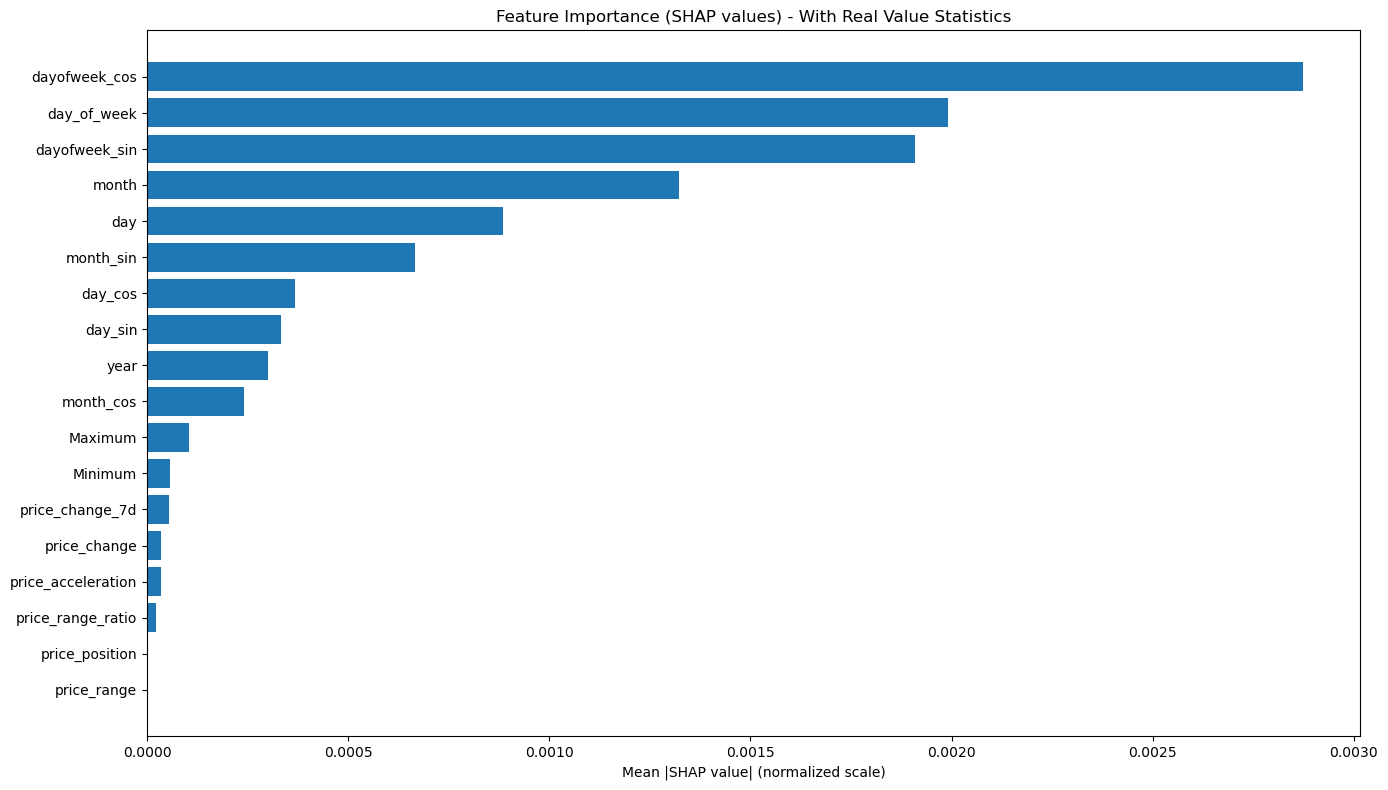

Creating SHAP summary plot with real values
SHAP values shape: (100, 18)
Real features shape: (100, 18)
Number of features: 18


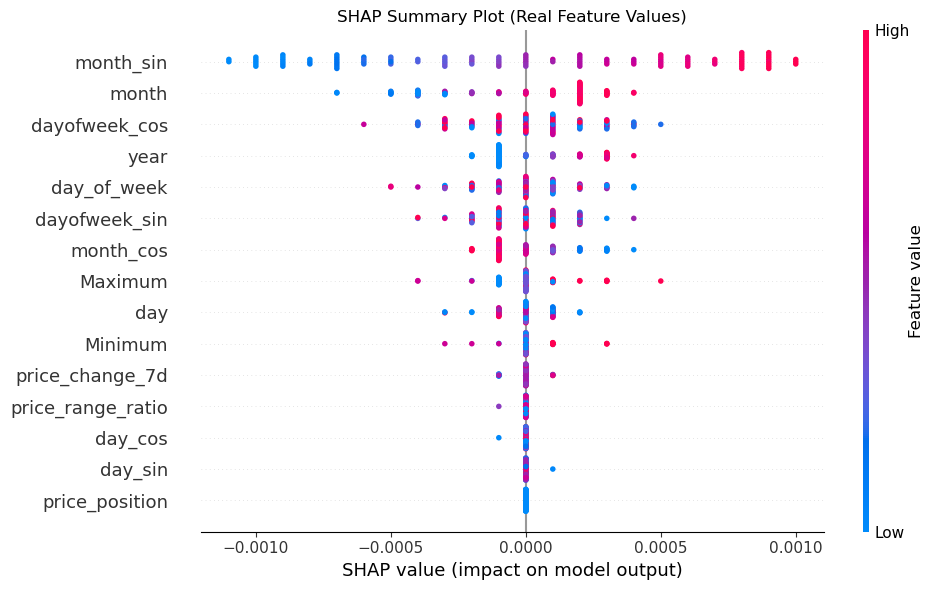

In [203]:
try:    
    # Initialize explainer for real values (use the corrected class name)
    print("\nCNN Model Explanations with Real Values:")
    cnn_explainer_real = DeepTimeSeriesExplainer(baseline_model.model, preprocessor)
    cnn_explanation_real = cnn_explainer_real.explain_predictions_real_values(
        X_test, y_test, commodities_test, feature_names, n_samples=100  # Add y_test parameter
    )
    
    print(f"SHAP values shape: {cnn_explanation_real['shap_values'].shape}")
    print(f"Real feature values shape: {cnn_explanation_real['X_real'].shape}")
    
    # Plot with real values
    cnn_explainer_real.plot_feature_importance_real(cnn_explanation_real)
    cnn_explainer_real.plot_shap_summary_real(cnn_explanation_real, max_display=15)
    
except Exception as e:
    print(f"Error during real values explainability analysis: {str(e)}")
    raise

Let's check the influence of the features in one prediction

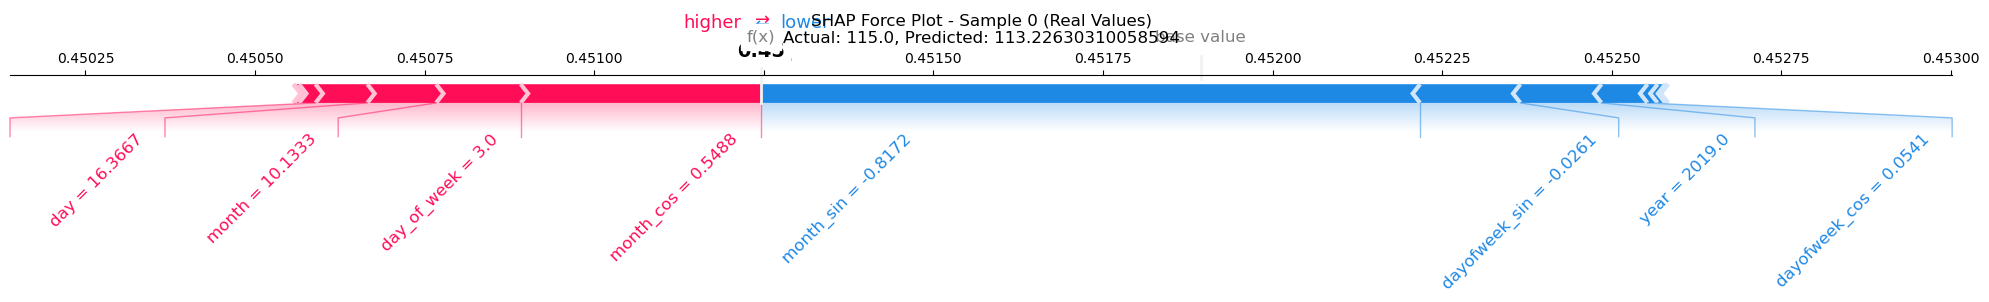

In [199]:
# Force plot with real values
cnn_explainer_real.plot_force_plot_real(cnn_explanation_real, sample_idx=0, matplotlib=True, 
                                        figsize=(20, 3), text_rotation=45)

A detailed explanation from the prediction is shown to analyze it better.

In [200]:
# Get detailed explanation with real values
details_real = cnn_explainer_real.get_prediction_explanation_real(cnn_explanation_real, sample_idx=0)
print("\nDetailed Explanation with Real Values:")
print(f"Actual Target: {details_real['actual_target']}")
print(f"Predicted Target: {details_real['predicted_target']}")
print(f"Prediction Error: {details_real['prediction_error']}")
print("\nTop Positive Features:")
for det in details_real['top_positive_features']:
    print(f"Feature: {det['feature']}, Real Value: {det['real_value']}, SHAP Value: {det['shap_value']}")

print("\nTop Negative Features:")
for det in details_real['top_negative_features']:
    print(f"Feature: {det['feature']}, Real Value: {det['real_value']}, SHAP Value: {det['shap_value']}")


Detailed Explanation with Real Values:
Actual Target: 115.0
Predicted Target: 113.2263
Prediction Error: 1.7737

Top Positive Features:
Feature: month_cos, Real Value: 0.5488, SHAP Value: 0.0004
Feature: day, Real Value: 16.3667, SHAP Value: 0.0001
Feature: month, Real Value: 10.1333, SHAP Value: 0.0001
Feature: day_of_week, Real Value: 3.0, SHAP Value: 0.0001
Feature: price_change_7d, Real Value: 0.0, SHAP Value: 0.0

Top Negative Features:
Feature: month_sin, Real Value: -0.8172, SHAP Value: -0.001
Feature: year, Real Value: 2019.0, SHAP Value: -0.0001
Feature: dayofweek_sin, Real Value: -0.0261, SHAP Value: -0.0001
Feature: dayofweek_cos, Real Value: 0.0541, SHAP Value: -0.0001
Feature: Minimum, Real Value: 110.0, SHAP Value: -0.0


Finally, a force plot over some predictions is shown.

In [ ]:
cnn_explainer_real.plot_force_plot_real(
    cnn_explanation_real, sample_idx=list(range(5)), matplotlib=False,
    figsize=(20, 3), text_rotation=45)

### Model 2 - Improvement - LSTM-CNN

Plots from improved model is also shown using the same base class.

CNN Model Explanations with Real Values:
SHAP values shape: (100, 30, 18)
Real feature values shape: (100, 30, 18)


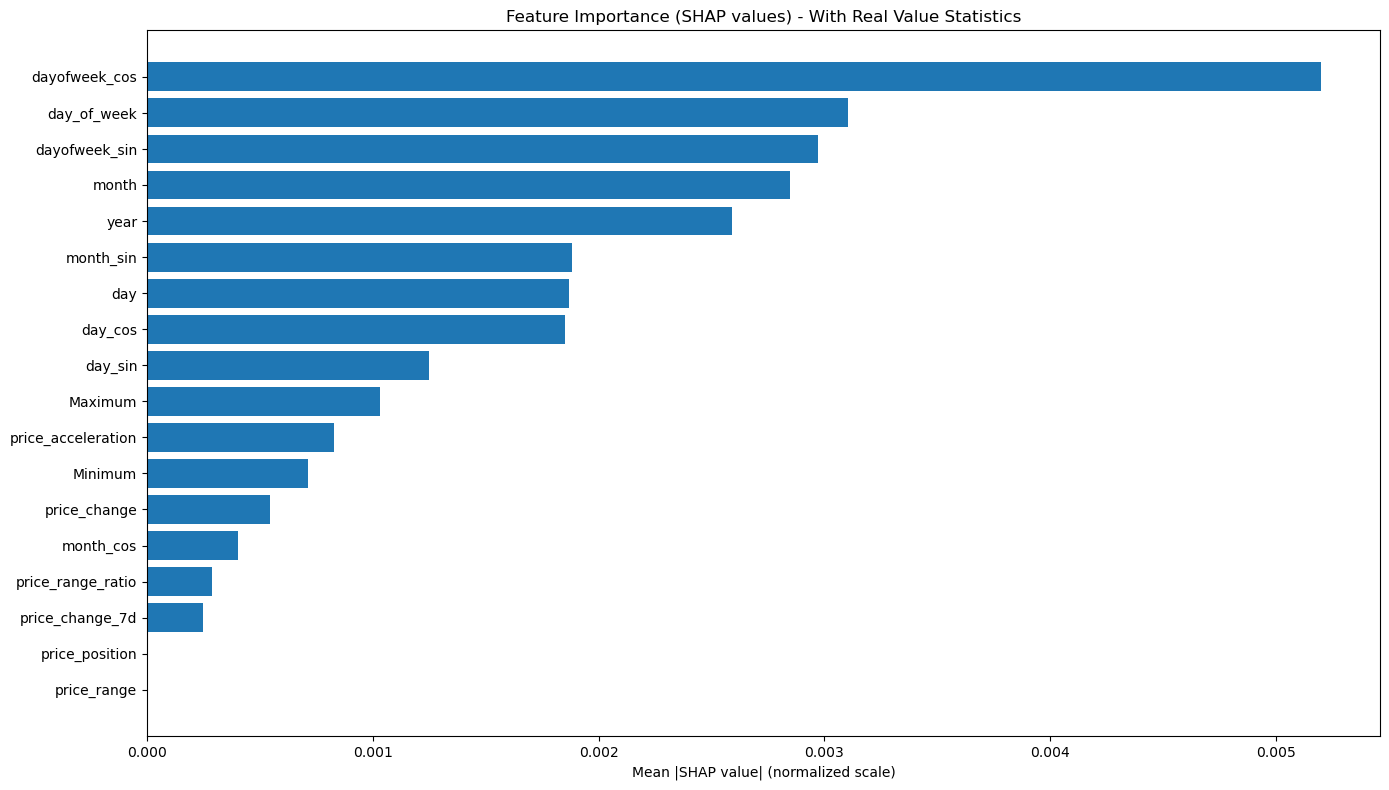

Creating SHAP summary plot with real values
SHAP values shape: (100, 18)
Real features shape: (100, 18)
Number of features: 18


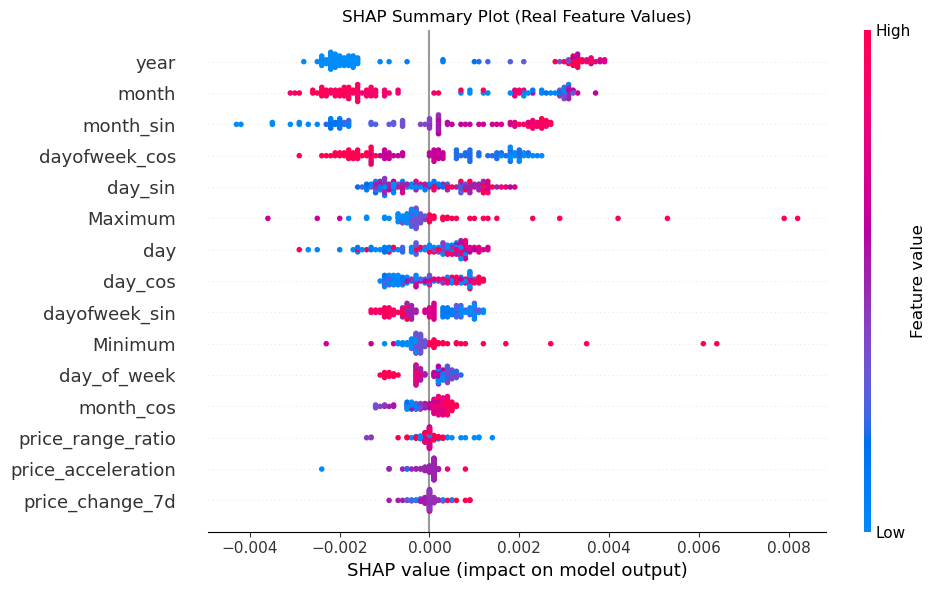

In [ ]:
try:    
    # Initialize explainer for real values (use the corrected class name)
    print("CNN Model Explanations with Real Values:")
    lstm_cnn_explainer = DeepTimeSeriesExplainer(improved_model_opt.model, preprocessor)
    lstm_cnn_explanation = lstm_cnn_explainer.explain_predictions_real_values(
        X_test, y_test, commodities_test, feature_names, n_samples=100)
    
    print(f"SHAP values shape: {lstm_cnn_explanation['shap_values'].shape}")
    print(f"Real feature values shape: {lstm_cnn_explanation['X_real'].shape}")
    
    # Plot with real values
    lstm_cnn_explainer.plot_feature_importance_real(lstm_cnn_explanation)
    lstm_cnn_explainer.plot_shap_summary_real(lstm_cnn_explanation, max_display=15)
    
except Exception as e:
    print(f"Error during real values explainability analysis: {str(e)}")
    raise

Let's check the influence of the features in one prediction

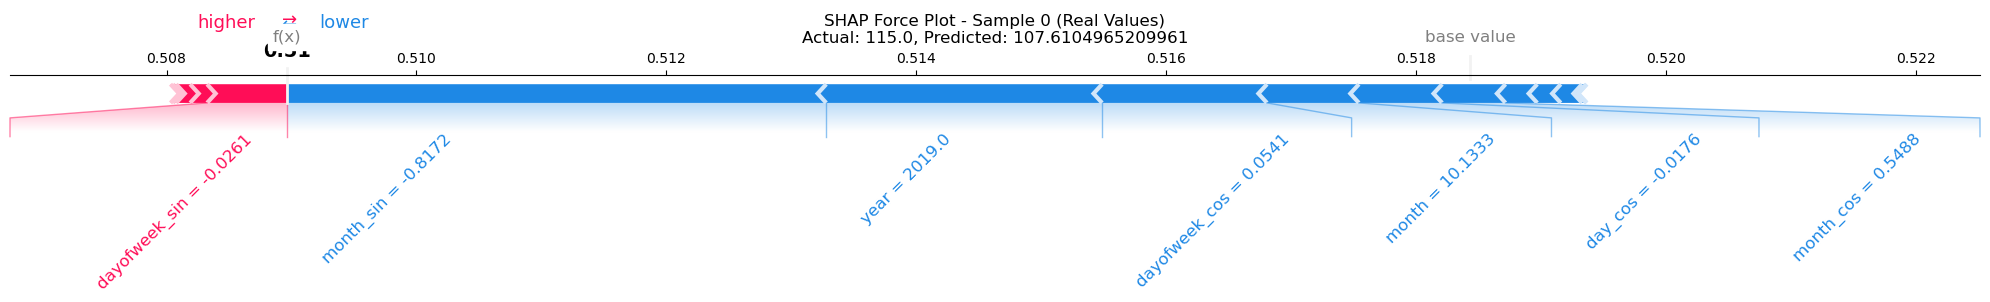

In [ ]:
# Single force plot for one sample
lstm_cnn_explainer.plot_force_plot_real(
    lstm_cnn_explanation, sample_idx=0, matplotlib=True, 
    figsize=(20, 3), text_rotation=45)

A detailed explanation from the prediction is shown to analyze it better.

In [ ]:
# Get detailed explanation with real values
details_real = cnn_explainer_real.get_prediction_explanation_real(cnn_explanation_real, sample_idx=0)
print("\nDetailed Explanation with Real Values:")
print(f"Actual Target: {details_real['actual_target']}")
print(f"Predicted Target: {details_real['predicted_target']}")
print(f"Prediction Error: {details_real['prediction_error']}")
print("\nTop Positive Features:")
for det in details_real['top_positive_features']:
    print(f"Feature: {det['feature']}, Real Value: {det['real_value']}, SHAP Value: {det['shap_value']}")

print("\nTop Negative Features:")
for det in details_real['top_negative_features']:
    print(f"Feature: {det['feature']}, Real Value: {det['real_value']}, SHAP Value: {det['shap_value']}")


Detailed Explanation with Real Values:
Actual Target: 115.0
Predicted Target: 113.2263
Prediction Error: 1.7737

Top Positive Features:
Feature: month_cos, Real Value: 0.5488, SHAP Value: 0.0004
Feature: month, Real Value: 10.1333, SHAP Value: 0.0002
Feature: day, Real Value: 16.3667, SHAP Value: 0.0001
Feature: Maximum, Real Value: 120.0, SHAP Value: 0.0
Feature: price_change, Real Value: 0.0, SHAP Value: 0.0

Top Negative Features:
Feature: month_sin, Real Value: -0.8172, SHAP Value: -0.0011
Feature: year, Real Value: 2019.0, SHAP Value: -0.0002
Feature: dayofweek_sin, Real Value: -0.0261, SHAP Value: -0.0001
Feature: Minimum, Real Value: 110.0, SHAP Value: -0.0
Feature: day_of_week, Real Value: 3.0, SHAP Value: -0.0


Finally, a force plot over some predictions is shown.

In [208]:
# lstm_cnn_explainer.plot_force_plot(lstm_cnn_explanation, X_test, sample_idx=list(range(5)), stacked=True)
lstm_cnn_explainer.plot_force_plot_real(
    lstm_cnn_explanation, sample_idx=list(range(5)), matplotlib=False,
    figsize=(20, 3), text_rotation=45)